# **Requirement 4: Slightly Non-Stationary Environments with Multiple Campaigns**

We expand the bidding architecture to a Combinatorial Multi-Armed Bandit problem with a global budget operating in a **piecewise-stationary (slightly non-stationary) environment**.

At each round $t$, the advertiser faces the identical combinatorial constraints (conflict graph) and budget limit $B$ established in previous requirements, but the underlying market dynamics are no longer static:
1. The total time horizon $T$ is partitioned into distinct, unknown intervals.
2. Within each specific interval, the vector of highest competing bids $\mathbf{m}_t$ is drawn from a fixed joint distribution. The distributions are different in each interval.
3. The advertiser still selects a combinatorial bid vector $\mathbf{b}_t$, wins auctions where $b_{i,t} \geq m_{i,t}$, and incurs costs/utilities identically, but must now actively track the evolving market to avoid optimizing for obsolete historical distributions.

The algorithm must dynamically adapt to these unannounced breakpoints while optimizing the combinatorial super-arm selection. We need to extend the Combinatorial-UCB approach from Requirement 2 using two distinct tracking mechanics:
* **Combinatorial-UCB with Sliding Window:** A passive adaptation policy that actively forgets older observations, calculating empirical means and confidence bounds using only a recent rolling window of history.
* **Combinatorial-UCB with a Change Detector:** An active adaptation policy that monitors the sequence of feedback for statistical drift and triggers a hard reset of its internal memory state when a distribution shift is detected.


In [31]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, norm

# Ensure project root is in path for imports
sys.path.append(os.path.abspath(os.path.join('..')))
from src.environments import BaseEnvironment
from src.multi_campign_environments import MultiCampaignEnvironment

In [90]:
import numpy as np
from scipy.stats import norm, beta as beta_dist


class SlightlyNonStationaryMultiCampaignEnvironment:
    """
    Req 4: Slightly non-stationary environment with arbitrary interval lengths.

    breakpoints      : list of round indices where a new interval starts.
                       Must include 0. e.g. [0, 200, 400] with T=600.
    dist_type        : 'gaussian', 'beta', or 'uniform'
    interval_configs : list of dicts, one per interval.
                       gaussian -> {"means": (N,), "stds":  (N,)}
                       beta     -> {"alphas": (N,), "betas": (N,)}
                       uniform  -> {"lows":  (N,), "highs": (N,)}
                       If None, random configs are generated.
    seed             : controls both config generation and pre-sampling.

    """
    def __init__(self, values, B, T, conflict_matrix,
                 breakpoints, dist_type='gaussian',
                 interval_configs=None, seed=None):

        self.values          = np.array(values, dtype=float)
        self.N               = len(self.values)
        self.conflict_matrix = np.array(conflict_matrix, dtype=bool)
        self.T               = int(T)
        self.B               = float(B)   # kept for reference/plotting; not enforced here
        self.dist_type       = dist_type
        self.t               = 0
        self.spent           = 0.0

        # ── Validate breakpoints ──────────────────────────────────────────────
        breakpoints = list(breakpoints)
        assert breakpoints[0] == 0,                        "First breakpoint must be 0."
        assert breakpoints == sorted(breakpoints),         "Breakpoints must be sorted."
        assert all(0 <= bp < T for bp in breakpoints),    "Breakpoints must be in [0, T)."

        self.breakpoints = breakpoints
        self.starts      = np.array(breakpoints, dtype=int)
        self.ends        = np.append(self.starts[1:], self.T)
        self.durations   = self.ends - self.starts
        self.n_intervals = len(breakpoints)

        # ── Build or validate interval configs ────────────────────────────────
        # interval_configs is PUBLIC so the outer script and clairvoyant
        # can access true distribution parameters via env.interval_configs
        rng = np.random.default_rng(seed)
        if interval_configs is None:
            self.interval_configs = self._random_configs(rng)
        else:
            assert len(interval_configs) == self.n_intervals, \
                f"Expected {self.n_intervals} configs, got {len(interval_configs)}"
            self.interval_configs = interval_configs

        # ── Pre-sample (T, N) competing bid matrix ────────────────────────────
        self.m_sequence = np.zeros((self.T, self.N))
        for k, cfg in enumerate(self.interval_configs):
            s, e = int(self.starts[k]), int(self.ends[k])
            dur  = e - s
            self.m_sequence[s:e] = self._sample(cfg, dur, rng)  # (dur, N)

        # ── Map each round to its interval index ──────────────────────────────
        self.round_to_interval = np.zeros(self.T, dtype=int)
        for k in range(self.n_intervals):
            self.round_to_interval[self.starts[k]:self.ends[k]] = k

    # ── Sampling ──────────────────────────────────────────────────────────────

    def _sample(self, cfg, size, rng):
        """Draw (size, N) competing bids from this interval's distribution."""
        out = np.zeros((size, self.N))
        for i in range(self.N):
            if self.dist_type == 'gaussian':
                out[:, i] = np.clip(
                    rng.normal(cfg["means"][i], cfg["stds"][i], size=size),
                    0.0, None)
            elif self.dist_type == 'beta':
                out[:, i] = rng.beta(cfg["alphas"][i], cfg["betas"][i], size=size)
            elif self.dist_type == 'uniform':
                out[:, i] = rng.uniform(cfg["lows"][i], cfg["highs"][i], size=size)
            else:
                raise ValueError(f"Unknown dist_type '{self.dist_type}'.")
        return out

    # ── Random config generation ──────────────────────────────────────────────

    def _random_configs(self, rng):
        configs = []
        for _ in range(self.n_intervals):
            if self.dist_type == 'gaussian':
                configs.append({
                    "means": rng.uniform(0.2, 0.8, size=self.N),
                    "stds":  rng.uniform(0.1, 0.3, size=self.N),
                })
            elif self.dist_type == 'beta':
                configs.append({
                    "alphas": rng.uniform(1.0, 5.0, size=self.N),
                    "betas":  rng.uniform(1.0, 5.0, size=self.N),
                })
            elif self.dist_type == 'uniform':
                lows  = rng.uniform(0.0, 0.4, size=self.N)
                highs = lows + rng.uniform(0.3, 0.6, size=self.N)
                configs.append({"lows": lows, "highs": highs})
        return configs

    # ── CDF — used by clairvoyant and for expected_net computation ────────────

    def win_prob(self, interval_idx, i, b):
        """
        P(m_i <= b) under interval interval_idx, campaign i.
        Public so the clairvoyant can call env.win_prob(k, i, b) directly.
        """
        cfg = self.interval_configs[interval_idx]
        if self.dist_type == 'gaussian':
            return norm.cdf(b, loc=cfg["means"][i], scale=cfg["stds"][i])
        elif self.dist_type == 'beta':
            return beta_dist.cdf(b, cfg["alphas"][i], cfg["betas"][i])
        elif self.dist_type == 'uniform':
            lo, hi = cfg["lows"][i], cfg["highs"][i]
            return np.clip((b - lo) / (hi - lo), 0.0, 1.0)

    # ── Auction resolution ────────────────────────────────────────────────────

    def resolve_auction(self, bid_vector):
        if self.t >= self.T:
            raise RuntimeError("Horizon T exceeded.")

        bid_vector   = np.array(bid_vector, dtype=float)
        interval_idx = int(self.round_to_interval[self.t])
        m_t          = self.m_sequence[self.t]

        # Conflict check
        active = np.where(bid_vector > 0.0)[0]
        for a in range(len(active)):
            for b in range(a + 1, len(active)):
                if self.conflict_matrix[active[a], active[b]]:
                    raise ValueError(
                        f"Conflict: campaigns {active[a]} and {active[b]}")

        # Expected net utility under current interval's true distribution
        win_probs    = np.array([self.win_prob(interval_idx, i, bid_vector[i])
                                 for i in range(self.N)])
        expected_net = float(np.sum((self.values - bid_vector) * win_probs))

        # Resolve auction
        won_vector = bid_vector >= m_t
        costs      = np.where(won_vector, bid_vector,               0.0)
        rewards    = np.where(won_vector, self.values - bid_vector, 0.0)

        self.spent += float(np.sum(costs))
        self.t     += 1

        return (won_vector, rewards, costs,
                {"expected_net": expected_net, "m_t": m_t,
                 "interval": interval_idx})

Code for the computation of the clairvoyant that returns gamma (M,) — optimal distrib over super-arms, 
super_arms (M, N) — bid index per campaign per super-arm and 
net_per_round : expected net utility per round with optimal distrib



In [91]:
def compute_clairvoyant(values, bid_space, B, T, conflict_matrix, cdf_functions):
    values = np.array(values, dtype=float)
    bid_space = np.array(bid_space, dtype=float)
    N, K = len(values), len(bid_space)
    rho = float(B) / float(T)

    # Injecting the distinct CDFs
    win_prob = np.zeros((N, K))
    for i in range(N):
        win_prob[i, :] = cdf_functions[i](bid_space)
    
    win_prob = np.clip(win_prob, 0.0, 1.0)

    # Net Expectations
    mu_f = (values[:, None] - bid_space[None, :]) * win_prob
    mu_c = bid_space[None, :] * win_prob

    # Pinning Inactivity
    mu_f[:, 0] = 0.0
    mu_c[:, 0] = 0.0

    valid_per_campaign = [[k for k, b in enumerate(bid_space) if b <= values[i]] for i in range(N)]
    valid_arms = []
    for combo in itertools.product(*valid_per_campaign):
        conflict = False
        for i in range(N):
            for j in range(i + 1, N):
                if conflict_matrix[i][j] and combo[i] != 0 and combo[j] != 0:
                    conflict = True
                    break
            if conflict: break
        if not conflict: valid_arms.append(combo)

    super_arms = np.array(valid_arms, dtype=int)
    M = len(super_arms)

    idx = np.arange(N)[None, :]
    U_sa = np.sum(mu_f[idx, super_arms], axis=1)
    C_sa = np.sum(mu_c[idx, super_arms], axis=1)

    res = optimize.linprog(
        -U_sa, A_ub=C_sa.reshape(1, -1), b_ub=np.array([rho]),
        A_eq=np.ones((1, M)), b_eq=np.array([1.0]),
        bounds=[(0.0, 1.0)] * M, method='highs-ds'
    )
    
    if not res.success:
        raise ValueError(f"Fluid LP failed: {res.message}")
        
    gamma = np.clip(res.x, 0.0, 1.0)
    gamma /= gamma.sum()
    net_per_round = float(np.dot(gamma, U_sa))
    
    return gamma, super_arms, net_per_round


Some plots to see the characteristics of the environment. You can vary the parameters : CONFLICT matrix, B budget, T rounds , BID_SPACE, values, BREAKPOINTS , the means and stds of distrib of each arm per interval ... 

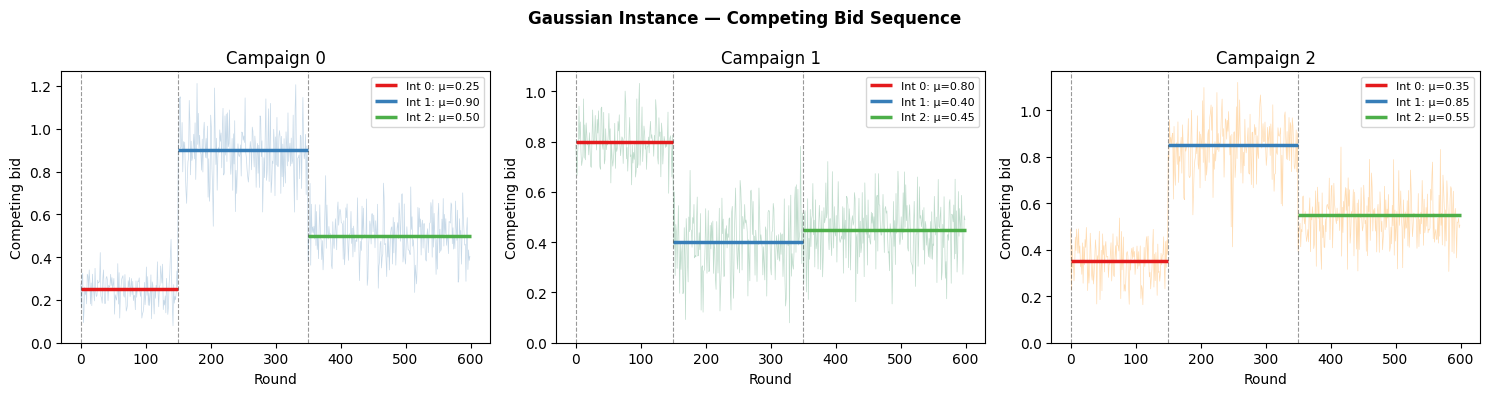

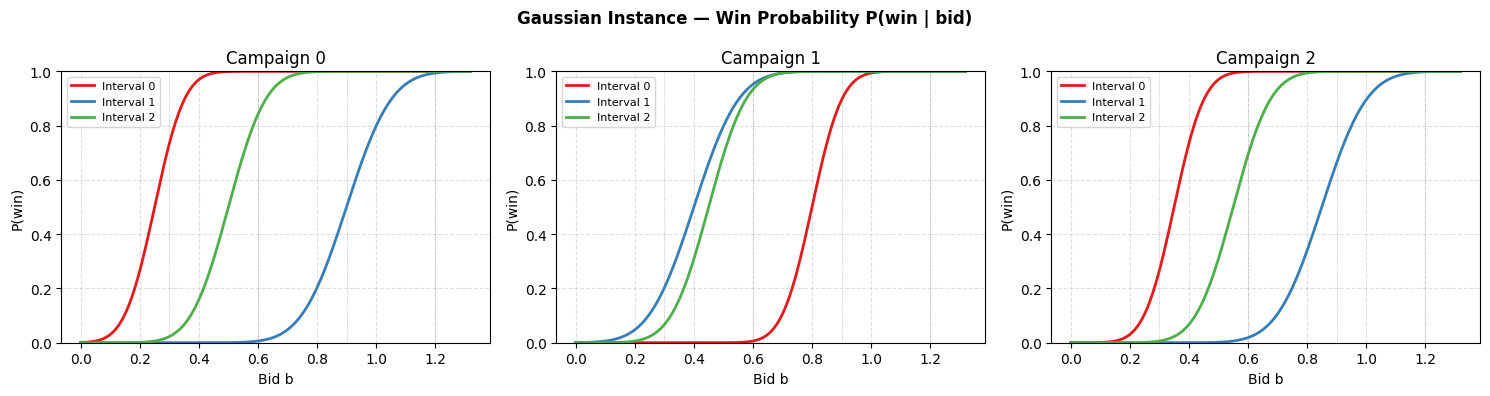

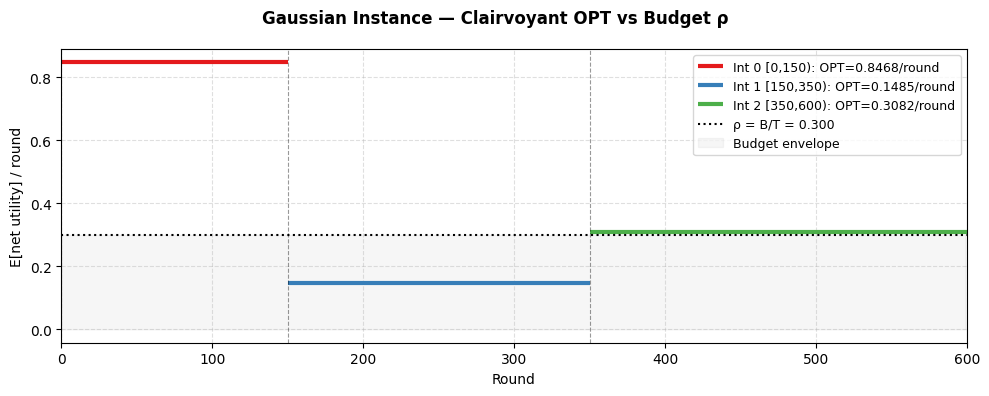

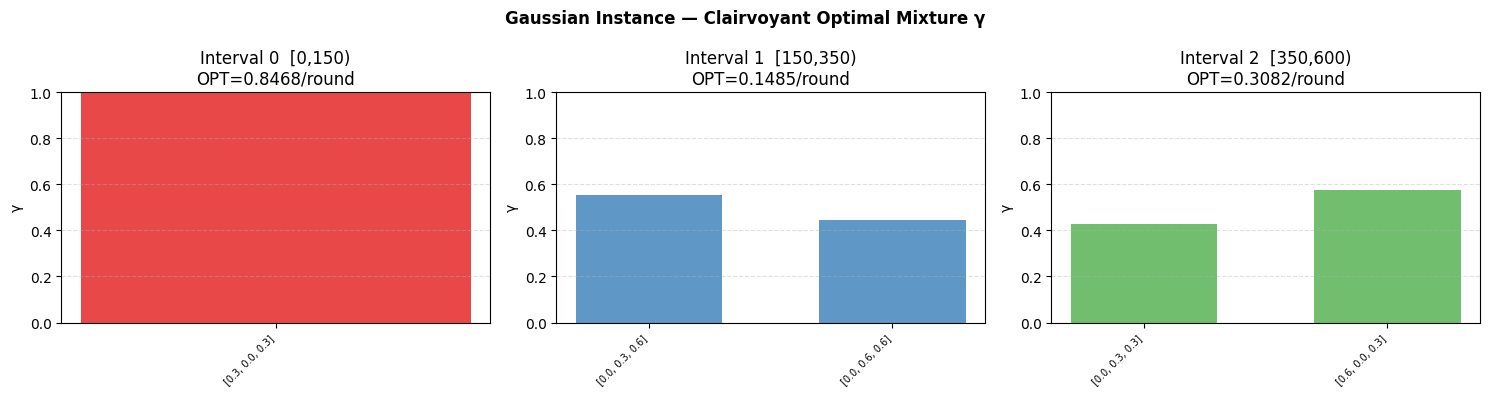

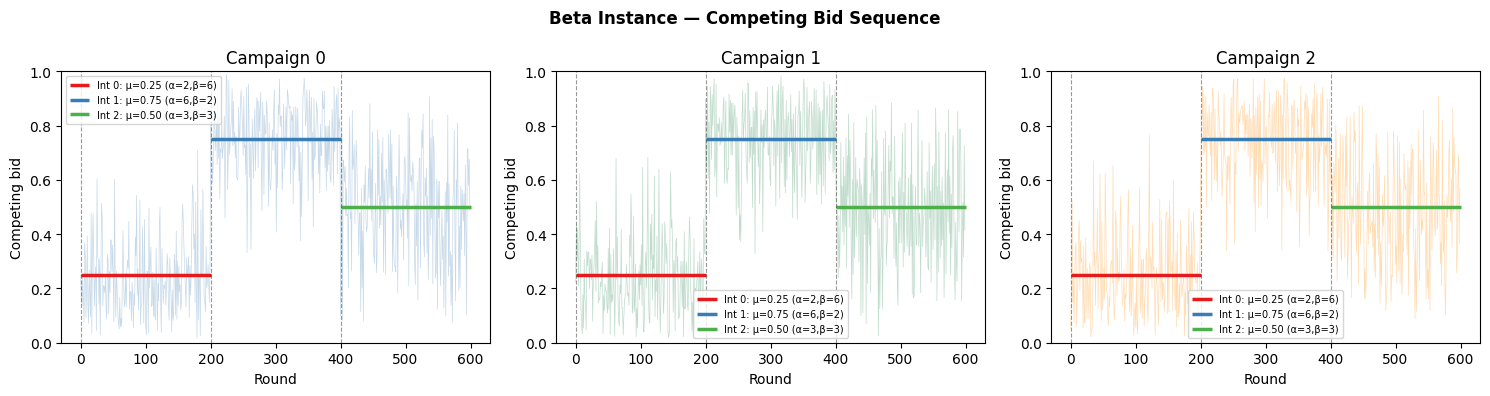

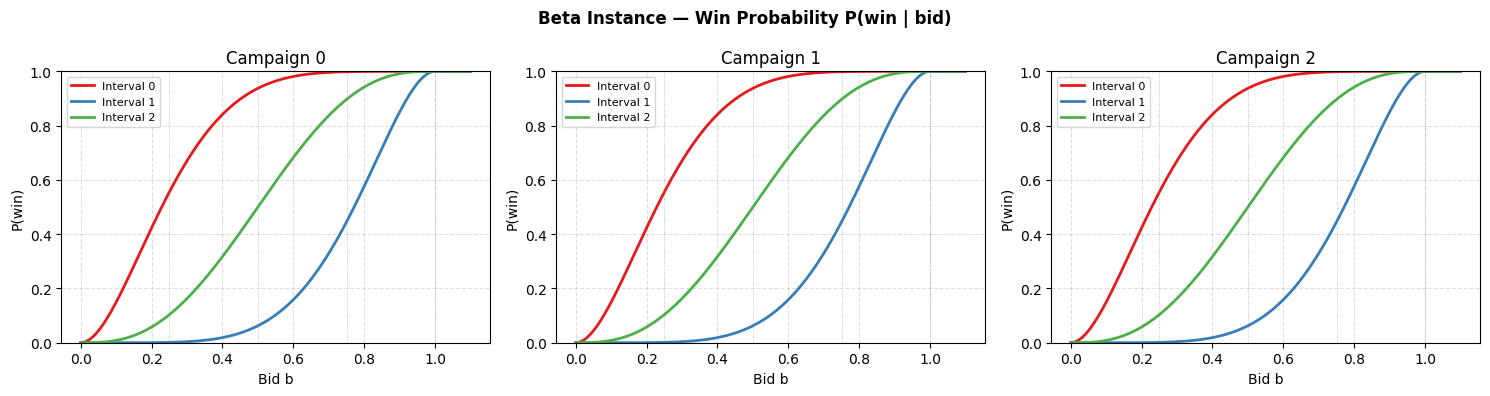

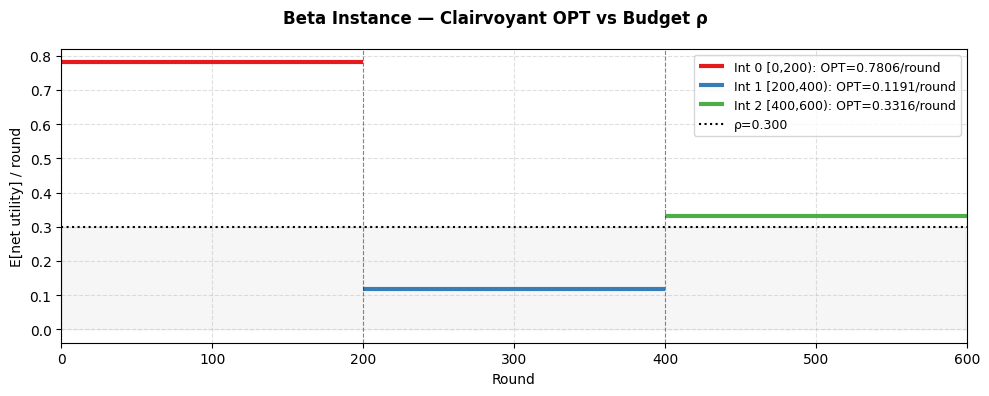

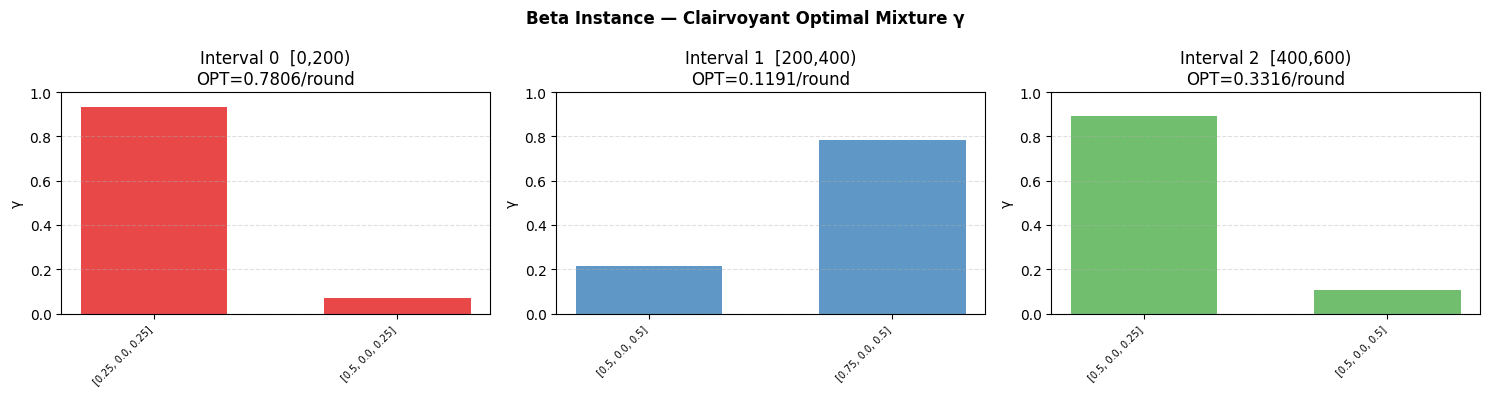

In [34]:
import numpy as np
import itertools
import matplotlib.pyplot as plt
from scipy.stats import norm, beta
from scipy import optimize

# ── Settings ──────────────────────────────────────────────────────────────────

VALUES      = [1.2, 0.8, 1.0]
BID_SPACE   = np.array([0.0, 0.3, 0.6, 0.9, 1.2])
T           = 600
B           = 0.3 * T
CONFLICT    = [[False, True,  False],
               [True,  False, False],
               [False, False, False]]
N           = 3
INT_COLORS  = ['#e41a1c', '#377eb8', '#4daf4a']
CAM_COLORS  = ['steelblue', 'seagreen', 'darkorange']

# ══════════════════════════════════════════════════════════════════════════════
# INSTANCE 1: GAUSSIAN — slow drift, means shift gradually across intervals
# Interesting because: budget is tight in interval 1 (high competition),
# agent must adapt bidding strategy.
# ══════════════════════════════════════════════════════════════════════════════

BREAKPOINTS_G = [0, 150, 350] 
# 3 intervals: [0,150), [150,350), [350,600)
gaussian_configs = [
    {"means": np.array([0.25, 0.8, 0.35]), "stds": np.array([0.08, 0.08, 0.08])}, 
    {"means": np.array([0.90, 0.4, 0.85]), "stds": np.array([0.12, 0.12, 0.12])},  
    {"means": np.array([0.50, 0.45, 0.55]), "stds": np.array([0.10, 0.10, 0.10])},  
]

env_g = SlightlyNonStationaryMultiCampaignEnvironment(
    values=VALUES, B=B, T=T, conflict_matrix=CONFLICT,
    breakpoints=BREAKPOINTS_G, dist_type='gaussian',
    interval_configs=gaussian_configs, seed=42)

# Clairvoyant per interval
cdfs_g = [
    [lambda b, m=gaussian_configs[k]["means"][i], s=gaussian_configs[k]["stds"][i]:
     norm.cdf(b, loc=m, scale=s) for i in range(N)]
    for k in range(env_g.n_intervals)
]
opt_g = [compute_clairvoyant(VALUES, BID_SPACE, B, T, CONFLICT, cdfs_g[k])
         for k in range(env_g.n_intervals)]
# opt_g[k] = (gamma, super_arms, net_per_round)

rho = B / T

# ── Plot 1a: Competing bid draws per campaign ─────────────────────────────────
rounds = np.arange(T)
fig, axes = plt.subplots(1, N, figsize=(15, 4))
fig.suptitle("Gaussian Instance — Competing Bid Sequence", fontweight='bold')
for i in range(N):
    axes[i].plot(rounds, env_g.m_sequence[:, i],
                 color=CAM_COLORS[i], alpha=0.3, lw=0.5)
    for k in range(env_g.n_intervals):
        s, e = int(env_g.starts[k]), int(env_g.ends[k])
        mu   = gaussian_configs[k]["means"][i]
        axes[i].hlines(mu, s, e,
                       colors=INT_COLORS[k], lw=2.5,
                       label=f"Int {k}: μ={mu:.2f}")
        axes[i].axvline(s, color='black', lw=0.8, linestyle='--', alpha=0.4)
    axes[i].set_title(f"Campaign {i}")
    axes[i].set_xlabel("Round")
    axes[i].set_ylabel("Competing bid")
    axes[i].set_ylim(bottom=0)
    axes[i].legend(fontsize=8)
plt.tight_layout()
plt.show()

# ── Plot 1b: Win probability curves per campaign ──────────────────────────────
bid_grid = np.linspace(0.0, BID_SPACE.max() * 1.1, 300)
fig, axes = plt.subplots(1, N, figsize=(15, 4))
fig.suptitle("Gaussian Instance — Win Probability P(win | bid)", fontweight='bold')
for i in range(N):
    for k in range(env_g.n_intervals):
        wp = np.array([env_g.win_prob(k, i, b) for b in bid_grid])
        axes[i].plot(bid_grid, wp,
                     color=INT_COLORS[k], lw=2,
                     label=f"Interval {k}")
    for b in BID_SPACE[1:]:
        axes[i].axvline(b, color='grey', lw=0.6, linestyle=':', alpha=0.6)
    axes[i].set_title(f"Campaign {i}")
    axes[i].set_xlabel("Bid b")
    axes[i].set_ylabel("P(win)")
    axes[i].set_ylim(0, 1)
    axes[i].legend(fontsize=8)
    axes[i].grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ── Plot 1c: Clairvoyant OPT per round vs rho ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle("Gaussian Instance — Clairvoyant OPT vs Budget ρ", fontweight='bold')
for k in range(env_g.n_intervals):
    s, e              = int(env_g.starts[k]), int(env_g.ends[k])
    _, _, net_k       = opt_g[k]
    ax.hlines(net_k, s, e,
              colors=INT_COLORS[k], lw=3,
              label=f"Int {k} [{s},{e}): OPT={net_k:.4f}/round")
    ax.axvline(s, color='black', lw=0.8, linestyle='--', alpha=0.4)
ax.axhline(rho, color='black', lw=1.5, linestyle=':',
           label=f"ρ = B/T = {rho:.3f}")
ax.fill_between(rounds, 0, rho, color='grey', alpha=0.07, label='Budget envelope')
ax.set_xlabel("Round")
ax.set_ylabel("E[net utility] / round")
ax.set_xlim(0, T)
ax.legend(fontsize=9)
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ── Plot 1d: Clairvoyant mixture weights per interval ─────────────────────────
fig, axes = plt.subplots(1, env_g.n_intervals,
                         figsize=(5 * env_g.n_intervals, 4))
fig.suptitle("Gaussian Instance — Clairvoyant Optimal Mixture γ", fontweight='bold')
for k in range(env_g.n_intervals):
    gamma_k, super_arms_k, net_k = opt_g[k]
    active = np.where(gamma_k > 1e-4)[0]
    labels = [str(np.round(BID_SPACE[super_arms_k[m]], 2).tolist())
              for m in active]
    axes[k].bar(np.arange(len(active)), gamma_k[active],
                color=INT_COLORS[k], alpha=0.8, width=0.6)
    axes[k].set_xticks(np.arange(len(active)))
    axes[k].set_xticklabels(labels, fontsize=7, rotation=45, ha='right')
    axes[k].set_title(f"Interval {k}  [{env_g.starts[k]},{env_g.ends[k]})\n"
                      f"OPT={net_k:.4f}/round")
    axes[k].set_ylabel("γ")
    axes[k].set_ylim(0, 1)
    axes[k].grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# INSTANCE 2: BETA — shape changes across intervals, not just mean
# Interval 0: left-skewed (easy), Interval 1: right-skewed (hard),
# Interval 2: symmetric (medium). Interesting because the shape change
# affects win probability non-linearly — a bid that was good in Int 0
# may be useless in Int 1.
# ══════════════════════════════════════════════════════════════════════════════

BREAKPOINTS_B = [0, 200, 400]   # equal intervals this time
beta_configs = [
    {"alphas": np.array([2., 2., 2.]), "betas": np.array([6., 6., 6.])},  # easy
    {"alphas": np.array([6., 6., 6.]), "betas": np.array([2., 2., 2.])},  # hard
    {"alphas": np.array([3., 3., 3.]), "betas": np.array([3., 3., 3.])},  # medium
]

env_b = SlightlyNonStationaryMultiCampaignEnvironment(
    values=[1.0, 0.7, 0.9], B=B, T=T, conflict_matrix=CONFLICT,
    breakpoints=BREAKPOINTS_B, dist_type='beta',
    interval_configs=beta_configs, seed=7)

# Beta lives on [0,1] — use rescaled bid space
BID_SPACE_B = BID_SPACE / BID_SPACE.max()  # [0, 0.25, 0.5, 0.75, 1.0]
VALUES_B    = [1.0, 0.7, 0.9]

cdfs_b = [
    [lambda b, a=beta_configs[k]["alphas"][i], bp=beta_configs[k]["betas"][i]:
     beta.cdf(np.clip(b, 0, 1), a, bp) for i in range(N)]
    for k in range(env_b.n_intervals)
]
opt_b = [compute_clairvoyant(VALUES_B, BID_SPACE_B, B, T, CONFLICT, cdfs_b[k])
         for k in range(env_b.n_intervals)]

# ── Plot 2a: Competing bid draws ──────────────────────────────────────────────
rounds = np.arange(T)
fig, axes = plt.subplots(1, N, figsize=(15, 4))
fig.suptitle("Beta Instance — Competing Bid Sequence", fontweight='bold')
for i in range(N):
    axes[i].plot(rounds, env_b.m_sequence[:, i],
                 color=CAM_COLORS[i], alpha=0.3, lw=0.5)
    for k in range(env_b.n_intervals):
        s, e  = int(env_b.starts[k]), int(env_b.ends[k])
        a_k   = beta_configs[k]["alphas"][i]
        b_k   = beta_configs[k]["betas"][i]
        mu    = a_k / (a_k + b_k)
        axes[i].hlines(mu, s, e,
                       colors=INT_COLORS[k], lw=2.5,
                       label=f"Int {k}: μ={mu:.2f} (α={a_k:.0f},β={b_k:.0f})")
        axes[i].axvline(s, color='black', lw=0.8, linestyle='--', alpha=0.4)
    axes[i].set_title(f"Campaign {i}")
    axes[i].set_xlabel("Round")
    axes[i].set_ylabel("Competing bid")
    axes[i].set_ylim(0, 1)
    axes[i].legend(fontsize=7)
plt.tight_layout()
plt.show()

# ── Plot 2b: Win probability curves ──────────────────────────────────────────
bid_grid_b = np.linspace(0.0, 1.1, 300)
fig, axes = plt.subplots(1, N, figsize=(15, 4))
fig.suptitle("Beta Instance — Win Probability P(win | bid)", fontweight='bold')
for i in range(N):
    for k in range(env_b.n_intervals):
        wp = np.array([env_b.win_prob(k, i, b) for b in bid_grid_b])
        axes[i].plot(bid_grid_b, wp,
                     color=INT_COLORS[k], lw=2, label=f"Interval {k}")
    for b in BID_SPACE_B[1:]:
        axes[i].axvline(b, color='grey', lw=0.6, linestyle=':', alpha=0.6)
    axes[i].set_title(f"Campaign {i}")
    axes[i].set_xlabel("Bid b")
    axes[i].set_ylabel("P(win)")
    axes[i].set_ylim(0, 1)
    axes[i].legend(fontsize=8)
    axes[i].grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ── Plot 2c: OPT vs rho ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle("Beta Instance — Clairvoyant OPT vs Budget ρ", fontweight='bold')
for k in range(env_b.n_intervals):
    s, e         = int(env_b.starts[k]), int(env_b.ends[k])
    _, _, net_k  = opt_b[k]
    ax.hlines(net_k, s, e,
              colors=INT_COLORS[k], lw=3,
              label=f"Int {k} [{s},{e}): OPT={net_k:.4f}/round")
    ax.axvline(s, color='black', lw=0.8, linestyle='--', alpha=0.4)
ax.axhline(rho, color='black', lw=1.5, linestyle=':',
           label=f"ρ={rho:.3f}")
ax.fill_between(rounds, 0, rho, color='grey', alpha=0.07)
ax.set_xlabel("Round")
ax.set_ylabel("E[net utility] / round")
ax.set_xlim(0, T)
ax.legend(fontsize=9)
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ── Plot 2d: Mixture weights ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, env_b.n_intervals,
                         figsize=(5 * env_b.n_intervals, 4))
fig.suptitle("Beta Instance — Clairvoyant Optimal Mixture γ", fontweight='bold')
for k in range(env_b.n_intervals):
    gamma_k, super_arms_k, net_k = opt_b[k]
    active = np.where(gamma_k > 1e-4)[0]
    labels = [str(np.round(BID_SPACE_B[super_arms_k[m]], 2).tolist())
              for m in active]
    axes[k].bar(np.arange(len(active)), gamma_k[active],
                color=INT_COLORS[k], alpha=0.8, width=0.6)
    axes[k].set_xticks(np.arange(len(active)))
    axes[k].set_xticklabels(labels, fontsize=7, rotation=45, ha='right')
    axes[k].set_title(f"Interval {k}  [{env_b.starts[k]},{env_b.ends[k]})\n"
                      f"OPT={net_k:.4f}/round")
    axes[k].set_ylabel("γ")
    axes[k].set_ylim(0, 1)
    axes[k].grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Learners in Slightly non stationary Environment: 

### Sliding Window C-UCB 

In [92]:
import numpy as np
from collections import deque
from scipy import optimize

from src.multi_campign_learners import C_UCB_Bidding

# ══════════════════════════════════════════════════════════════════════════════
# SLIDING WINDOW AGENT
# ══════════════════════════════════════════════════════════════════════════════

class SW_C_UCB_Bidding(C_UCB_Bidding):
    """
    Sliding Window variant of C_UCB for non-stationary environments.
    Keeps only the last W observations per (campaign i, bid k) pair.
    """
    def __init__(self, values, bid_space, B, T, conflict_matrix, W):
        super().__init__(values, bid_space, B, T, conflict_matrix)
        self.W = int(W)

        self._f_history = [[deque(maxlen=W) for _ in range(self.K)] for _ in range(self.N)]
        self._c_history = [[deque(maxlen=W) for _ in range(self.K)] for _ in range(self.N)]

    def update(self, won_vector, util_vector, cost_vector):
        self.spent += float(np.sum(cost_vector))

        for i in range(self.N):
            k = int(self.last_action_indices[i])
            self._f_history[i][k].append(float(util_vector[i]))
            self._c_history[i][k].append(float(cost_vector[i]))

            self.N_pulls[i, k] = len(self._f_history[i][k])
            self.avg_f[i, k]   = np.mean(self._f_history[i][k])
            self.avg_c[i, k]   = np.mean(self._c_history[i][k])

        self.t += 1

    def _get_bounds(self):
        pulled = self.N_pulls > 0
        radius = np.zeros((self.N, self.K))

        effective_t = min(self.t + 1, self.W)
        log_term = np.log(T)
        radius[pulled] = np.sqrt(2.0 * log_term / self.N_pulls[pulled])

        max_net = np.max(self.values[:, None] - self.bid_space[None, :], axis=1)
        f_ucbs  = np.where(pulled,(self.avg_f + max_net[:, None] * radius), max_net[:, None])
        c_lcbs  = np.where(pulled, (self.avg_c - radius), 1e-8)

        f_ucbs[:, 0] = 0.0
        c_lcbs[:, 0] = 0.0
        return f_ucbs, c_lcbs

# ══════════════════════════════════════════════════════════════════════════════
# SUBCLASSES
# ══════════════════════════════════════════════════════════════════════════════

class SW_LP_Agent(SW_C_UCB_Bidding):
    """Sliding Window + Optimistic LP mixture."""
    def pull_arm(self):
        rem_b = self.budget - self.spent
        rem_r = max(self.T_horizon - self.t, 1.0)
        if rem_b < self.max_possible_cost or rem_r <= 0:
            return self._safe_fallback()

        f_ucbs, c_lcbs = self._get_bounds()
        idx  = np.arange(self.N)
        U_sa = np.sum(f_ucbs[idx, self.super_arms], axis=1)
        C_sa = np.sum(c_lcbs[idx, self.super_arms], axis=1)

        res = optimize.linprog(
            -U_sa,
            A_ub=C_sa.reshape(1, -1), b_ub=[rem_b / rem_r],
            A_eq=np.ones((1, self.M)), b_eq=[1.0],
            bounds=[(0.0, 1.0)] * self.M, method='highs-ds'
        )
        if res.success:
            gamma  = np.clip(res.x, 0.0, 1.0)
            gamma /= gamma.sum()
        else:
            gamma = np.zeros(self.M)
            gamma[np.argmin(C_sa)] = 1.0

        self.last_sa_idx = np.random.choice(self.M, p=gamma)
        self.last_action_indices = self.super_arms[self.last_sa_idx]
        return self.bid_space[self.last_action_indices]


class SW_LP_MeanCost_Agent(SW_C_UCB_Bidding):
    """Sliding Window + LP mixture utilizing Empirical Mean Cost."""
    def pull_arm(self):
        rem_b = self.budget - self.spent
        rem_r = max(self.T_horizon - self.t, 1.0)
        if rem_b < self.max_possible_cost or rem_r <= 0:
            return self._safe_fallback()

        f_ucbs, _ = self._get_bounds()
        idx  = np.arange(self.N)
        U_sa = np.sum(f_ucbs[idx, self.super_arms], axis=1)

        c_hats = np.where(self.N_pulls > 0, self.avg_c, 1e-8)
        c_hats[:, 0] = 0.0
        C_sa_hat = np.sum(c_hats[idx, self.super_arms], axis=1)

        res = optimize.linprog(
            -U_sa,
            A_ub=C_sa_hat.reshape(1, -1), b_ub=[rem_b / rem_r],
            A_eq=np.ones((1, self.M)), b_eq=[1.0],
            bounds=[(0.0, 1.0)] * self.M, method='highs-ds'
        )
        if res.success:
            gamma  = np.clip(res.x, 0.0, 1.0)
            gamma /= gamma.sum()
        else:
            gamma = np.zeros(self.M)
            gamma[np.argmin(C_sa_hat)] = 1.0

        self.last_sa_idx = np.random.choice(self.M, p=gamma)
        self.last_action_indices = self.super_arms[self.last_sa_idx]
        return self.bid_space[self.last_action_indices]


class SW_Greedy_Agent(SW_C_UCB_Bidding):
    """Sliding Window + Greedy Argmax heuristic."""
    def pull_arm(self):
        rem_b = self.budget - self.spent
        rem_r = max(self.T_horizon - self.t, 1.0)
        if rem_b < self.max_possible_cost or rem_r <= 0:
            return self._safe_fallback()

        f_ucbs, c_lcbs = self._get_bounds()
        idx  = np.arange(self.N)
        U_sa = np.sum(f_ucbs[idx, self.super_arms], axis=1)
        C_sa = np.sum(c_lcbs[idx, self.super_arms], axis=1)

        rho        = rem_b / rem_r
        valid_mask = C_sa <= rho
        if np.any(valid_mask):
            chosen_idx = np.argmax(np.where(valid_mask, U_sa, -np.inf))
        else:
            chosen_idx = np.argmin(C_sa)

        self.last_sa_idx = chosen_idx
        self.last_action_indices = self.super_arms[chosen_idx]
        return self.bid_space[self.last_action_indices]

In [93]:
import numpy as np
import itertools
from scipy import optimize


def compute_joint_piecewise_clairvoyant(env, bid_space):
    """

    Unlike a per-interval solve with a fixed rho=B/T, this solves one joint
    LP across all intervals simultaneously: a separate randomized policy
    gamma_k per interval, but a single shared budget constraint

        sum_k duration_k * (gamma_k . C_sa_k)  <=  B

    coupling them together. This lets the clairvoyant shift budget away
    from intervals where it's not the bottleneck and toward intervals
    where it is -- something a uniform rho=B/T per interval cannot do,
    since it treats every interval as if it had its own independent
    B/T-sized budget, which is more restrictive than the real
    problem

    Returns:
      net_per_round_by_interval : (n_intervals,) the achieved per-round
          rate in each interval under the JOINTLY optimal allocation
      cumulative_baseline       : (T,) piecewise-linear cumulative benchmark
      gammas                    : list of (M,) arrays, the optimal policy
          per interval
      super_arms                : (M, N) the shared action set
    """
    N = env.N
    bid_space_arr = np.array(bid_space, dtype=float)
    values = env.values
    n_intervals = env.n_intervals
    durations = env.durations.astype(float)   # weight of each interval in the total

    valid_per_campaign = [[k for k, b in enumerate(bid_space_arr) if b <= values[i]] for i in range(N)]
    valid_arms = []
    for combo in itertools.product(*valid_per_campaign):
        conflict = False
        for i in range(N):
            for j in range(i + 1, N):
                if env.conflict_matrix[i][j] and combo[i] != 0 and combo[j] != 0:
                    conflict = True
                    break
            if conflict: break
        if not conflict: valid_arms.append(combo)
    super_arms = np.array(valid_arms, dtype=int)
    M = len(super_arms)
    idx = np.arange(N)[None, :]

    # For each interval, using that interval's own true win probabilities,
    # compute every super-arm's expected reward (U_sa_k) and cost (C_sa_k).
    # Same math as the single-interval clairvoyant, just repeated per phase.
    U_sa_list, C_sa_list = [], []
    for k in range(n_intervals):
        win_prob = np.zeros((N, len(bid_space_arr)))
        for i in range(N):
            win_prob[i, :] = env.win_prob(k, i, bid_space_arr)
        win_prob = np.clip(win_prob, 0.0, 1.0)
        mu_f = (values[:, None] - bid_space_arr[None, :]) * win_prob
        mu_c = bid_space_arr[None, :] * win_prob
        mu_f[:, 0] = 0.0   # abstain always gives exactly 0 reward...
        mu_c[:, 0] = 0.0   # ...and exactly 0 cost, pinned exactly rather than trusting the CDF at 0
        U_sa_list.append(np.sum(mu_f[idx, super_arms], axis=1))
        C_sa_list.append(np.sum(mu_c[idx, super_arms], axis=1))

    # ---- 1 joint LP over all intervals at once ----
    # Variables: gamma_0, gamma_1, ..., gamma_{K-1} concatenated (one length-M
    # distribution per interval), rather than solving each interval alone.
    total_vars = n_intervals * M

    # Objective: maximize total reward = sum over intervals of
    # duration_k * (gamma_k . U_sa_k) -- longer intervals count for more.
    c = np.concatenate([-durations[k] * U_sa_list[k] for k in range(n_intervals)])

    # the key constraint: total expected spend across all intervals combined
    # must respect the one shared budget B. A single row spanning every
    # interval's variables -- this is what lets the solver move budget from
    # an unprofitable interval to a profitable one, instead of forcing the
    # same B/T rate everywhere.
    A_ub = np.concatenate([durations[k] * C_sa_list[k] for k in range(n_intervals)]).reshape(1, -1)
    b_ub = np.array([env.B])

    # Each interval's own gamma_k must still be a valid distribution
    # (sums to 1) -- one such constraint per interval, block-diagonal so
    # intervals don't interfere with each other's action choice, only share
    # the budget above.
    A_eq = np.zeros((n_intervals, total_vars))
    for k in range(n_intervals):
        A_eq[k, k * M:(k + 1) * M] = 1.0
    b_eq = np.ones(n_intervals)

    res = optimize.linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq,
                            bounds=[(0.0, 1.0)] * total_vars, method='highs-ds')
    if not res.success:
        raise ValueError(f"Joint fluid LP failed: {res.message}")

    # Unpack the single solution vector back into one gamma_k per interval.
    gammas = []
    for k in range(n_intervals):
        g = np.clip(res.x[k * M:(k + 1) * M], 0.0, 1.0)
        g = g / max(g.sum(), 1e-12)
        gammas.append(g)

    # Achieved per-round rate in each interval under the jointly optimal plan.
    net_per_round_by_interval = np.array([float(np.dot(gammas[k], U_sa_list[k])) for k in range(n_intervals)])

    # Stitch into a piecewise-linear cumulative curve: climb at each
    # interval's own rate for its own duration, handing off where the
    # previous interval left off.
    cumulative_baseline = np.zeros(env.T)
    for k in range(n_intervals):
        s, e = int(env.starts[k]), int(env.ends[k])
        prior = cumulative_baseline[s - 1] if s > 0 else 0.0
        cumulative_baseline[s:e] = prior + np.arange(1, e - s + 1) * net_per_round_by_interval[k]

    return net_per_round_by_interval, cumulative_baseline, gammas, super_arms

Piecewise fluid OPT per interval:
  interval 0 (t=0-400): 0.8139/round
  interval 1 (t=400-1000): 0.0228/round

Simulating T=1000...


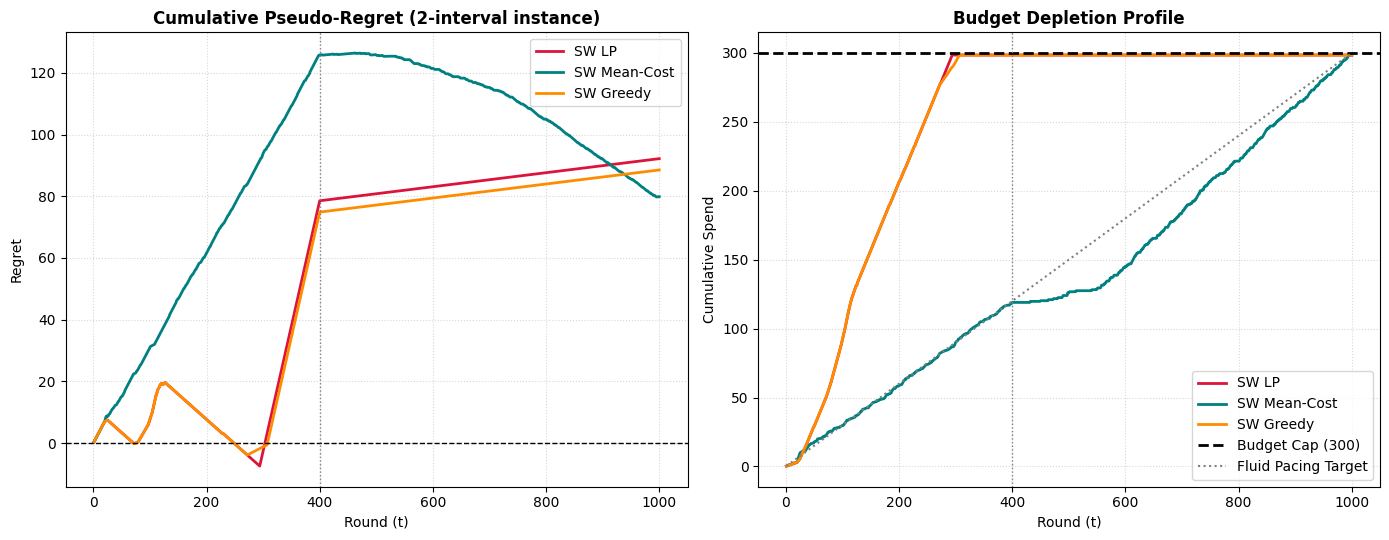


Agent            | Final Pseudo-Regret  | Final Spend    
------------------------------------------------------------
SW LP            | 92.20                | 298.50/300.00
SW Mean-Cost     | 79.89                | 298.50/300.00
SW Greedy        | 88.53                | 298.50/300.00


In [94]:
# ── SMALL, EASY INSTANCE ──────────────────────────────────────────────────
# 2 campaigns, NO conflict, ONE breakpoint (2 intervals of equal length),
# distributions far apart so the shift is obvious. Good for a quick sanity
# check before scaling up to the bigger 4-phase instance.
VALUES      = [1.0, 1.0]
BID_SPACE   = [0.0, 0.25, 0.5, 0.75, 1.0]
T           = 1000
B           = 0.3 * T
W           = 60
CONFLICT    = [[False, False], [False, False]]
BREAKPOINTS = [0, 400]
SEED        = 1

CONFIGS = [
    {"means": [0.3, 0.3], "stds": [0.1, 0.1]},   # phase 0: easy, cheap wins
    {"means": [0.7, 0.7], "stds": [0.1, 0.1]},   # phase 1: hard, need higher bids
]

AGENT_CLASSES = {
    "SW LP":        SW_LP_Agent,
    "SW Mean-Cost": SW_LP_MeanCost_Agent,
    "SW Greedy":    SW_Greedy_Agent,
}
COLORS = {"SW LP": "crimson", "SW Mean-Cost": "teal", "SW Greedy": "darkorange"}


def make_env():
    return SlightlyNonStationaryMultiCampaignEnvironment(
        VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian',
        interval_configs=CONFIGS, seed=SEED
    )


if __name__ == "__main__":
    env_baseline = make_env()
    net_per_interval, cumulative_baseline, gammas, super_arms = compute_joint_piecewise_clairvoyant(env_baseline, BID_SPACE)
    print("Piecewise fluid OPT per interval:")
    for k in range(env_baseline.n_intervals):
        print(f"  interval {k} (t={env_baseline.starts[k]}-{env_baseline.ends[k]}): {net_per_interval[k]:.4f}/round")

    agents = {name: cls(VALUES, BID_SPACE, B, T, CONFLICT, W) for name, cls in AGENT_CLASSES.items()}
    envs = {name: make_env() for name in agents}
    results = {name: {"expected_net": np.zeros(T), "spend": np.zeros(T)} for name in agents}

    print(f"\nSimulating T={T}...")
    for t in range(T):
        for name, agent in agents.items():
            bids = agent.pull_arm()
            won_vector, util_vector, cost_vector, info = envs[name].resolve_auction(bids)
            agent.update(won_vector, util_vector, cost_vector)
            results[name]["expected_net"][t] = info["expected_net"]
            results[name]["spend"][t] = envs[name].spent

    for name in agents:
        results[name]["pseudo_regret"] = cumulative_baseline - np.cumsum(results[name]["expected_net"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    rounds = np.arange(1, T + 1)

    for name in agents:
        axes[0].plot(rounds, results[name]["pseudo_regret"], color=COLORS[name], lw=2, label=name)
    axes[0].axhline(0, color='black', linestyle='--', lw=1)
    for bp in BREAKPOINTS[1:]:
        axes[0].axvline(bp, color='gray', linestyle=':', lw=1)
    axes[0].set_title("Cumulative Pseudo-Regret (2-interval instance)", fontweight='bold')
    axes[0].set_xlabel("Round (t)"); axes[0].set_ylabel("Regret")
    axes[0].legend(); axes[0].grid(True, linestyle=':', alpha=0.5)

    for name in agents:
        axes[1].plot(rounds, results[name]["spend"], color=COLORS[name], lw=2, label=name)
    axes[1].axhline(B, color='black', lw=2, linestyle='--', label=f"Budget Cap ({B:.0f})")
    axes[1].plot(rounds, (B / T) * rounds, color='gray', lw=1.5, linestyle=':', label="Fluid Pacing Target")
    for bp in BREAKPOINTS[1:]:
        axes[1].axvline(bp, color='gray', linestyle=':', lw=1)
    axes[1].set_title("Budget Depletion Profile", fontweight='bold')
    axes[1].set_xlabel("Round (t)"); axes[1].set_ylabel("Cumulative Spend")
    axes[1].legend(); axes[1].grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

    print(f"\n{'Agent':<16} | {'Final Pseudo-Regret':<20} | {'Final Spend':<15}")
    print("-" * 60)
    for name in agents:
        print(f"{name:<16} | {results[name]['pseudo_regret'][-1]:<20.2f} | {results[name]['spend'][-1]:.2f}/{B:.2f}")

M = 64 valid super-arms
Piecewise fluid OPT per interval:
  interval 0 (t=0-600): 0.2961/round
  interval 1 (t=600-1200): 0.2550/round
  interval 2 (t=1200-1800): 0.9155/round
  interval 3 (t=1800-2400): 0.0967/round
  interval 4 (t=2400-3000): 0.2685/round
  interval 5 (t=3000-3600): 0.3192/round

Simulating T=3600...


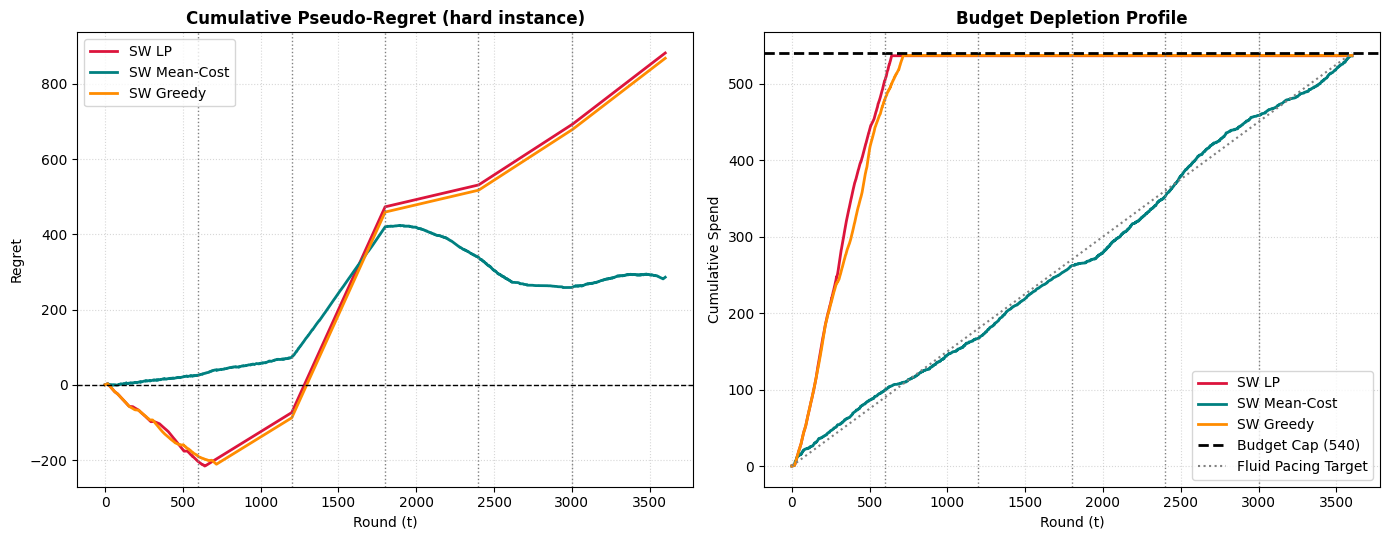


Agent            | Final Pseudo-Regret  | Final Spend    
------------------------------------------------------------
SW LP            | 882.19               | 536.40/540.00
SW Mean-Cost     | 285.97               | 536.20/540.00
SW Greedy        | 868.23               | 536.80/540.00


In [95]:
# ── HARD INSTANCE ─────────────────────────────────────────────────────────
# 4 campaigns, a TRIANGLE conflict among 0,1,2 (at most one of them can be
# active at once -- exactly the case where a naive pairwise set-packing
# relaxation would be wrong, forcing genuine super-arm enumeration), 6
# SHORT phases (600 rounds each, much shorter than the previous instance's
# 500) with SUBTLE mean shifts (0.10-0.15 apart, not dramatic swings) and a
# tighter budget. Much harder to track than the earlier "easy"/"main"
# instances: frequent switching relative to the window size W, and shifts
# small enough that noticing them at all is non-trivial.
VALUES      = [1.2, 1.0, 1.1, 0.6]
BID_SPACE   = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
T           = 3600
B           = 0.15 * T
W           = 250
CONFLICT    = [
    [False, True,  True,  False],
    [True,  False, True,  False],
    [True,  True,  False, False],
    [False, False, False, False],
]
BREAKPOINTS = [0, 600, 1200, 1800, 2400, 3000]
SEED        = 7

CONFIGS = [
    {"means": [0.35, 0.40, 0.30, 0.25], "stds": [0.08, 0.08, 0.08, 0.08]},
    {"means": [0.45, 0.35, 0.35, 0.30], "stds": [0.08, 0.08, 0.08, 0.08]},
    {"means": [0.30, 0.45, 0.40, 0.20], "stds": [0.08, 0.08, 0.08, 0.08]},
    {"means": [0.40, 0.30, 0.45, 0.35], "stds": [0.08, 0.08, 0.08, 0.08]},
    {"means": [0.25, 0.40, 0.30, 0.40], "stds": [0.08, 0.08, 0.08, 0.08]},
    {"means": [0.40, 0.25, 0.40, 0.25], "stds": [0.08, 0.08, 0.08, 0.08]},
]

AGENT_CLASSES = {
    "SW LP":        SW_LP_Agent,
    "SW Mean-Cost": SW_LP_MeanCost_Agent,
    "SW Greedy":    SW_Greedy_Agent,
}
COLORS = {"SW LP": "crimson", "SW Mean-Cost": "teal", "SW Greedy": "darkorange"}


def make_env():
    return SlightlyNonStationaryMultiCampaignEnvironment(
        VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian',
        interval_configs=CONFIGS, seed=SEED
    )


if __name__ == "__main__":
    env_baseline = make_env()
    net_per_interval, cumulative_baseline, gammas, super_arms = compute_joint_piecewise_clairvoyant(env_baseline, BID_SPACE)
    print(f"M = {len(super_arms)} valid super-arms")
    print("Piecewise fluid OPT per interval:")
    for k in range(env_baseline.n_intervals):
        print(f"  interval {k} (t={env_baseline.starts[k]}-{env_baseline.ends[k]}): {net_per_interval[k]:.4f}/round")

    agents = {name: cls(VALUES, BID_SPACE, B, T, CONFLICT, W) for name, cls in AGENT_CLASSES.items()}
    envs = {name: make_env() for name in agents}
    results = {name: {"expected_net": np.zeros(T), "spend": np.zeros(T)} for name in agents}

    print(f"\nSimulating T={T}...")
    for t in range(T):
        for name, agent in agents.items():
            bids = agent.pull_arm()
            won_vector, util_vector, cost_vector, info = envs[name].resolve_auction(bids)
            agent.update(won_vector, util_vector, cost_vector)
            results[name]["expected_net"][t] = info["expected_net"]
            results[name]["spend"][t] = envs[name].spent

    for name in agents:
        results[name]["pseudo_regret"] = cumulative_baseline - np.cumsum(results[name]["expected_net"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    rounds = np.arange(1, T + 1)

    for name in agents:
        axes[0].plot(rounds, results[name]["pseudo_regret"], color=COLORS[name], lw=2, label=name)
    axes[0].axhline(0, color='black', linestyle='--', lw=1)
    for bp in BREAKPOINTS[1:]:
        axes[0].axvline(bp, color='gray', linestyle=':', lw=1)
    axes[0].set_title("Cumulative Pseudo-Regret (hard instance)", fontweight='bold')
    axes[0].set_xlabel("Round (t)"); axes[0].set_ylabel("Regret")
    axes[0].legend(); axes[0].grid(True, linestyle=':', alpha=0.5)

    for name in agents:
        axes[1].plot(rounds, results[name]["spend"], color=COLORS[name], lw=2, label=name)
    axes[1].axhline(B, color='black', lw=2, linestyle='--', label=f"Budget Cap ({B:.0f})")
    axes[1].plot(rounds, (B / T) * rounds, color='gray', lw=1.5, linestyle=':', label="Fluid Pacing Target")
    for bp in BREAKPOINTS[1:]:
        axes[1].axvline(bp, color='gray', linestyle=':', lw=1)
    axes[1].set_title("Budget Depletion Profile", fontweight='bold')
    axes[1].set_xlabel("Round (t)"); axes[1].set_ylabel("Cumulative Spend")
    axes[1].legend(); axes[1].grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

    print(f"\n{'Agent':<16} | {'Final Pseudo-Regret':<20} | {'Final Spend':<15}")
    print("-" * 60)
    for name in agents:
        print(f"{name:<16} | {results[name]['pseudo_regret'][-1]:<20.2f} | {results[name]['spend'][-1]:.2f}/{B:.2f}")

Piecewise fluid OPT per interval (joint-optimal budget allocation):
  interval 0 (t=0-500): 0.8413/round
  interval 1 (t=500-1000): 0.0013/round
  interval 2 (t=1000-1500): 0.5573/round
  interval 3 (t=1500-2000): 1.0000/round

Simulating T=2000...


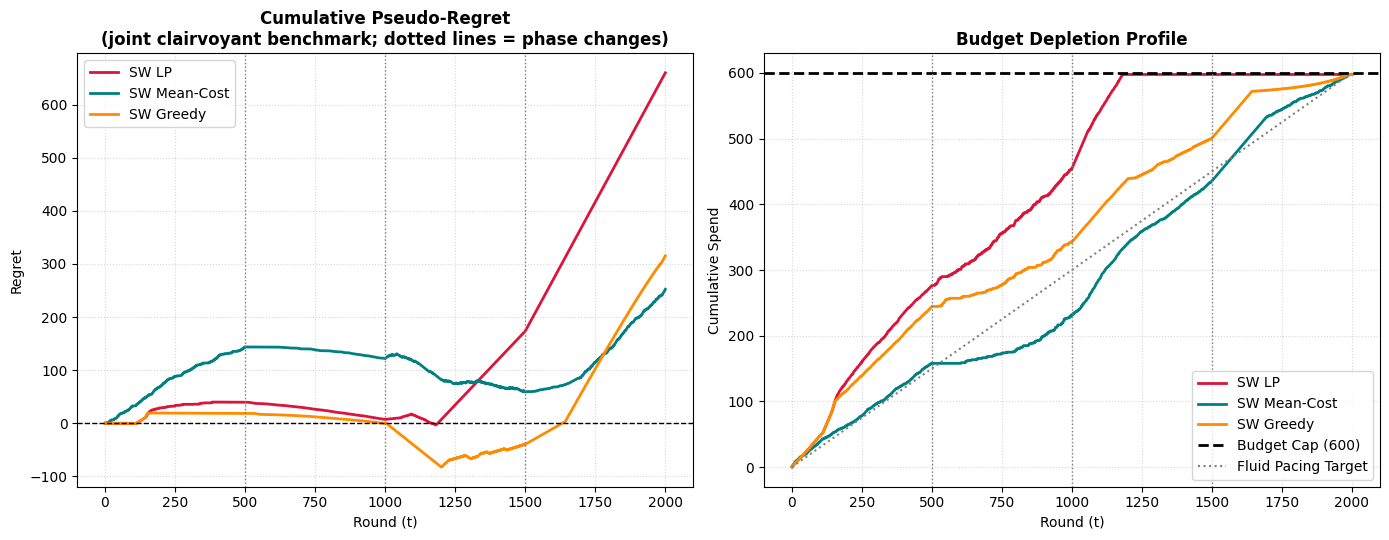


Agent            | Final Pseudo-Regret  | Final Spend    
------------------------------------------------------------
SW LP            | 659.73               | 597.50/600.00
SW Mean-Cost     | 252.15               | 597.50/600.00
SW Greedy        | 315.16               | 597.50/600.00


In [96]:
# ── 1. INSTANCE PARAMETERS ───────────────────────────────────────────────────
VALUES      = [1.5, 1.2]
BID_SPACE   = [0.0, 0.5, 1.0, 1.5]
T           = 2000
B           = 0.3 * T
W           = 200
CONFLICT    = [[False, True], [True, False]]
BREAKPOINTS = [0, 500, 1000, 1500]
SEED        = 42   # passed explicitly to the environment -- np.random.seed()
                    # alone does NOT seed it, since it uses default_rng internally

# 4 phases
CONFIGS = [
    {"means": [0.4, 0.3], "stds": [0.1,  0.1 ]},   # phase 0: weak
    {"means": [1.1, 1.0], "stds": [0.2,  0.2 ]},   # phase 1: both strong (competing bids high -> thin margins)
    {"means": [0.3, 1.2], "stds": [0.1,  0.2 ]},   # phase 2: campaign 1 dominant
    {"means": [0.2, 0.1], "stds": [0.05, 0.05]},   # phase 3: weak again
]

AGENT_CLASSES = {
    "SW LP":        SW_LP_Agent,
    "SW Mean-Cost": SW_LP_MeanCost_Agent,
    "SW Greedy":    SW_Greedy_Agent,
}
COLORS = {"SW LP": "crimson", "SW Mean-Cost": "teal", "SW Greedy": "darkorange"}


def make_env():
    # same seed + same interval_configs every call -> identical market draws
    # across all three agents (common random numbers)
    return SlightlyNonStationaryMultiCampaignEnvironment(
        VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian',
        interval_configs=CONFIGS, seed=SEED
    )


if __name__ == "__main__":
    # ── 2. Piecewise clairvoyant baseline (JOINT budget allocation) ─────────
    env_baseline = make_env()
    net_per_interval, cumulative_baseline, gammas, super_arms = compute_joint_piecewise_clairvoyant(env_baseline, BID_SPACE)
    print("Piecewise fluid OPT per interval (joint-optimal budget allocation):")
    for k in range(env_baseline.n_intervals):
        print(f"  interval {k} (t={env_baseline.starts[k]}-{env_baseline.ends[k]}): {net_per_interval[k]:.4f}/round")

    # ── 3. Run all three agents ──────────────────────────────────────────────
    agents = {name: cls(VALUES, BID_SPACE, B, T, CONFLICT, W) for name, cls in AGENT_CLASSES.items()}
    envs = {name: make_env() for name in agents}
    results = {name: {"expected_net": np.zeros(T), "spend": np.zeros(T)} for name in agents}

    print(f"\nSimulating T={T}...")
    for t in range(T):
        for name, agent in agents.items():
            bids = agent.pull_arm()
            won_vector, util_vector, cost_vector, info = envs[name].resolve_auction(bids)
            agent.update(won_vector, util_vector, cost_vector)

            results[name]["expected_net"][t] = info["expected_net"]
            results[name]["spend"][t] = envs[name].spent

    for name in agents:
        results[name]["pseudo_regret"] = cumulative_baseline - np.cumsum(results[name]["expected_net"])

    # ── 4. Plotting ───────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    rounds = np.arange(1, T + 1)

    for name in agents:
        axes[0].plot(rounds, results[name]["pseudo_regret"], color=COLORS[name], lw=2, label=name)
    axes[0].axhline(0, color='black', linestyle='--', lw=1)
    for bp in BREAKPOINTS[1:]:
        axes[0].axvline(bp, color='gray', linestyle=':', lw=1)
    axes[0].set_title("Cumulative Pseudo-Regret\n(joint clairvoyant benchmark; dotted lines = phase changes)", fontweight='bold')
    axes[0].set_xlabel("Round (t)"); axes[0].set_ylabel("Regret")
    axes[0].legend(); axes[0].grid(True, linestyle=':', alpha=0.5)

    for name in agents:
        axes[1].plot(rounds, results[name]["spend"], color=COLORS[name], lw=2, label=name)
    axes[1].axhline(B, color='black', lw=2, linestyle='--', label=f"Budget Cap ({B:.0f})")
    axes[1].plot(rounds, (B / T) * rounds, color='gray', lw=1.5, linestyle=':', label="Fluid Pacing Target")
    for bp in BREAKPOINTS[1:]:
        axes[1].axvline(bp, color='gray', linestyle=':', lw=1)
    axes[1].set_title("Budget Depletion Profile", fontweight='bold')
    axes[1].set_xlabel("Round (t)"); axes[1].set_ylabel("Cumulative Spend")
    axes[1].legend(); axes[1].grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

    print(f"\n{'Agent':<16} | {'Final Pseudo-Regret':<20} | {'Final Spend':<15}")
    print("-" * 60)
    for name in agents:
        print(f"{name:<16} | {results[name]['pseudo_regret'][-1]:<20.2f} | {results[name]['spend'][-1]:.2f}/{B:.2f}")

### Testing different W values (window sizes)

Piecewise fluid OPT per interval:
  interval 0 (t=0-500): 0.8413/round
  interval 1 (t=500-1000): 0.0013/round
  interval 2 (t=1000-1500): 0.5573/round
  interval 3 (t=1500-2000): 1.0000/round

Simulating T=2000 for 8 window sizes...
  W=  25  final regret=  269.37  final spend=597.50/600.00
  W=  50  final regret=  253.75  final spend=597.50/600.00
  W= 100  final regret=  292.01  final spend=597.50/600.00
  W= 150  final regret=  275.21  final spend=597.50/600.00
  W= 200  final regret=  287.39  final spend=597.50/600.00
  W= 300  final regret=  331.64  final spend=597.50/600.00
  W= 500  final regret=  293.71  final spend=597.50/600.00
  W= 750  final regret=  261.88  final spend=597.50/600.00


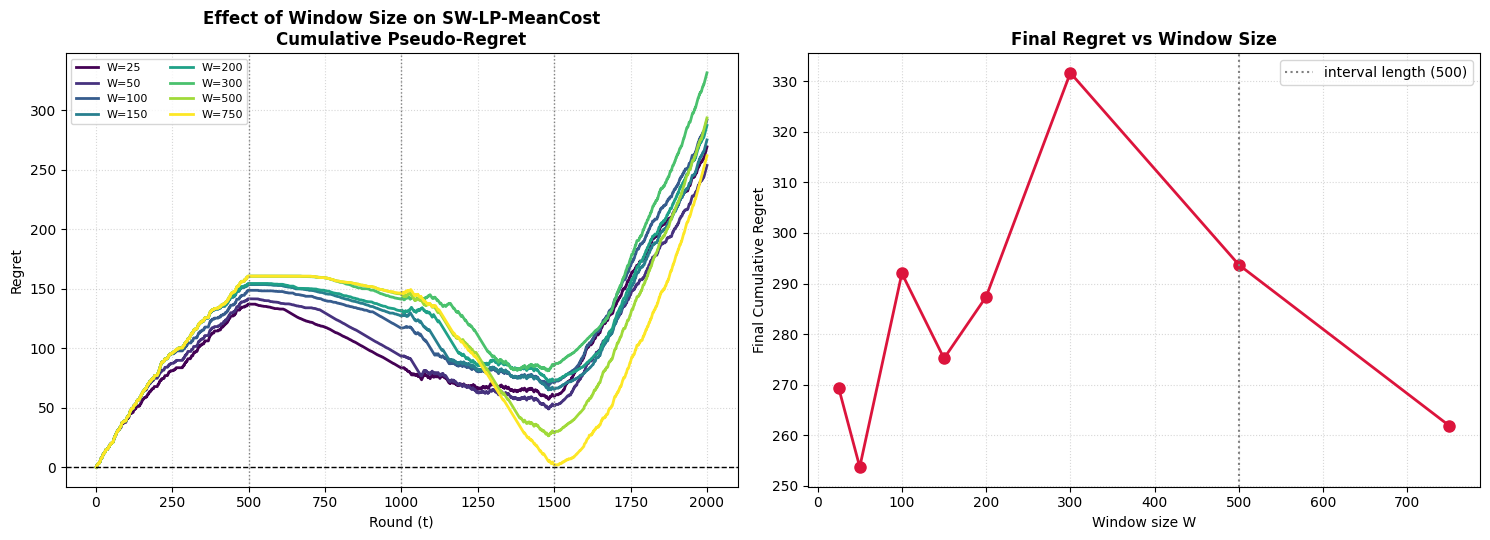


W        | Final Pseudo-Regret  | Final Spend    
--------------------------------------------------
25       | 269.37               | 597.50/600.00
50       | 253.75               | 597.50/600.00
100      | 292.01               | 597.50/600.00
150      | 275.21               | 597.50/600.00
200      | 287.39               | 597.50/600.00
300      | 331.64               | 597.50/600.00
500      | 293.71               | 597.50/600.00
750      | 261.88               | 597.50/600.00


In [97]:
# ── INSTANCE: the "main" 4-phase instance used throughout ───────────────────
VALUES      = [1.5, 1.2]
BID_SPACE   = [0.0, 0.5, 1.0, 1.5]
T           = 2000
B           = 0.3 * T
CONFLICT    = [[False, True], [True, False]]
BREAKPOINTS = [0, 500, 1000, 1500]   # interval length = 500
SEED        = 42

CONFIGS = [
    {"means": [0.4, 0.3], "stds": [0.1,  0.1 ]},
    {"means": [1.1, 1.0], "stds": [0.2,  0.2 ]},
    {"means": [0.3, 1.2], "stds": [0.1,  0.2 ]},
    {"means": [0.2, 0.1], "stds": [0.05, 0.05]},
]

# spans well below, near, and well above the interval length (500), to show
# the full tradeoff: too small -> noisy estimates, too large -> window still
# mixes stale pre-change data with fresh post-change data for too long
W_VALUES = [25, 50, 100, 150, 200, 300, 500, 750]

COLORS = plt.cm.viridis(np.linspace(0, 1, len(W_VALUES)))


def make_env():
    return SlightlyNonStationaryMultiCampaignEnvironment(
        VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian',
        interval_configs=CONFIGS, seed=SEED
    )


if __name__ == "__main__":
    env_baseline = make_env()
    net_per_interval, cumulative_baseline, gammas, super_arms = compute_joint_piecewise_clairvoyant(env_baseline, BID_SPACE)
    print("Piecewise fluid OPT per interval:")
    for k in range(env_baseline.n_intervals):
        print(f"  interval {k} (t={env_baseline.starts[k]}-{env_baseline.ends[k]}): {net_per_interval[k]:.4f}/round")

    rounds = np.arange(1, T + 1)
    all_regret = {}
    final_regret = {}
    final_spend = {}

    print(f"\nSimulating T={T} for {len(W_VALUES)} window sizes...")
    for W in W_VALUES:
        np.random.seed(42)              # matched RNG start across W values
        env = make_env()                # same seed -> common random numbers across W values
        agent = SW_LP_MeanCost_Agent(VALUES, BID_SPACE, B, T, CONFLICT, W)

        expected_net = np.zeros(T)
        for t in range(T):
            bids = agent.pull_arm()
            won, rew, cost, info = env.resolve_auction(bids)
            agent.update(won, rew, cost)
            expected_net[t] = info["expected_net"]

        pseudo_regret = cumulative_baseline - np.cumsum(expected_net)
        all_regret[W] = pseudo_regret
        final_regret[W] = pseudo_regret[-1]
        final_spend[W] = env.spent
        print(f"  W={W:4d}  final regret={pseudo_regret[-1]:8.2f}  final spend={env.spent:.2f}/{B:.2f}")

    # ── Plotting: full regret curves + final-regret-vs-W summary ────────────
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

    for color, W in zip(COLORS, W_VALUES):
        axes[0].plot(rounds, all_regret[W], color=color, lw=2, label=f"W={W}")
    axes[0].axhline(0, color='black', linestyle='--', lw=1)
    for bp in BREAKPOINTS[1:]:
        axes[0].axvline(bp, color='gray', linestyle=':', lw=1)
    axes[0].set_title("Effect of Window Size on SW-LP-MeanCost\nCumulative Pseudo-Regret", fontweight='bold')
    axes[0].set_xlabel("Round (t)"); axes[0].set_ylabel("Regret")
    axes[0].legend(fontsize=8, ncol=2); axes[0].grid(True, linestyle=':', alpha=0.5)

    axes[1].plot(W_VALUES, [final_regret[W] for W in W_VALUES], 'o-', color='crimson', lw=2, markersize=8)
    axes[1].axvline(T / env_baseline.n_intervals, color='gray', linestyle=':', lw=1.5,
                     label=f"interval length ({T // env_baseline.n_intervals})")
    axes[1].set_title("Final Regret vs Window Size", fontweight='bold')
    axes[1].set_xlabel("Window size W"); axes[1].set_ylabel("Final Cumulative Regret")
    axes[1].legend(); axes[1].grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

    print(f"\n{'W':<8} | {'Final Pseudo-Regret':<20} | {'Final Spend':<15}")
    print("-" * 50)
    for W in W_VALUES:
        print(f"{W:<8} | {final_regret[W]:<20.2f} | {final_spend[W]:.2f}/{B:.2f}")

### C-UCB with Change detector : 

In [98]:
import numpy as np
from scipy import optimize

from src.multi_campign_learners import C_UCB_Bidding

# ══════════════════════════════════════════════════════════════════════════════
# CUSUM CHANGE DETECTOR
# ══════════════════════════════════════════════════════════════════════════════

class CD_C_UCB_Bidding(C_UCB_Bidding):
    """
    Change-detector variant of C_UCB for non-stationary environments.

    Standard two-sided CUSUM per (campaign, bid) pair:
      1. WARM-UP: the first `warmup` samples after each reset are used only
         to estimate a reference mean mu0, not tested for a change.
      2. mu0 is then FROZEN. All subsequent samples accumulate
             g_pos = max(0, g_pos + (x - mu0 - delta))
             g_neg = max(0, g_neg + (mu0 - x - delta))
         and an alarm fires once either exceeds lambda_th.
    """
    def __init__(self, values, bid_space, B, T, conflict_matrix,
                 warmup=10, delta=0.05, lambda_th=1.0):
        super().__init__(values, bid_space, B, T, conflict_matrix)
        self.warmup = int(warmup)
        self.delta = delta
        self.lambda_th = lambda_th
        self.n_resets = 0
        self._reset_detector()

    def _reset_detector(self):
        """Hard reset of empirical stats, CUSUM trackers, and local epoch."""
        self.avg_f = np.zeros((self.N, self.K))
        self.avg_c = np.zeros((self.N, self.K))
        self.N_pulls = np.zeros((self.N, self.K))

        # Local epoch clock to prevent np.log(t) explosion post-reset
        self.t_epoch = 0

        # mu0[i,k] is None until warm-up completes for that (campaign, bid)
        self._mu0 = np.full((self.N, self.K), np.nan)
        self._warmup_sum = np.zeros((self.N, self.K))
        self._warmup_n   = np.zeros((self.N, self.K), dtype=int)

        self._g_pos = np.zeros((self.N, self.K))
        self._g_neg = np.zeros((self.N, self.K))

    def _cusum_update(self, i, k, x):
        """Returns True if a positive or negative drift exceeds lambda_th."""
        if self._warmup_n[i, k] < self.warmup:
            # still warming up: accumulate toward mu0, don't test yet
            self._warmup_sum[i, k] += x
            self._warmup_n[i, k]   += 1
            if self._warmup_n[i, k] == self.warmup:
                self._mu0[i, k] = self._warmup_sum[i, k] / self.warmup
            return False

        mu0 = self._mu0[i, k]
        self._g_pos[i, k] = max(0.0, self._g_pos[i, k] + (x - mu0 - self.delta))
        self._g_neg[i, k] = max(0.0, self._g_neg[i, k] + (mu0 - x - self.delta))
        return (self._g_pos[i, k] > self.lambda_th) or (self._g_neg[i, k] > self.lambda_th)

    def update(self, won_vector, util_vector, cost_vector):
        self.spent += float(np.sum(cost_vector))

        change_detected = False
        for i in range(self.N):
            k = int(self.last_action_indices[i])
            self.N_pulls[i, k] += 1
            n = self.N_pulls[i, k]

            x_val = float(util_vector[i])
            self.avg_f[i, k] += (x_val - self.avg_f[i, k]) / n
            self.avg_c[i, k] += (float(cost_vector[i]) - self.avg_c[i, k]) / n

            if self._cusum_update(i, k, x_val):
                change_detected = True

        if change_detected:
            self.n_resets += 1
            self._reset_detector()
        else:
            self.t_epoch += 1

        self.t += 1

    def _get_bounds(self):
        """Overrides base to utilize t_epoch instead of absolute t."""
        pulled = self.N_pulls > 0
        radius = np.zeros((self.N, self.K))

        safe_t = max(self.t_epoch, 1)
        radius[pulled] = np.sqrt(2.0 * np.log(safe_t + 1) / self.N_pulls[pulled])

        max_net = np.max(self.values[:, None] - self.bid_space[None, :], axis=1)
        f_ucbs  = np.where(pulled, np.minimum(self.avg_f + max_net[:, None] * radius, max_net[:, None]), max_net[:, None])
        c_lcbs  = np.where(pulled, np.maximum(self.avg_c - radius, 1e-8), 1e-8)

        f_ucbs[:, 0], c_lcbs[:, 0] = 0.0, 0.0
        return f_ucbs, c_lcbs

# ══════════════════════════════════════════════════════════════════════════════
# SUBCLASSES
# ══════════════════════════════════════════════════════════════════════════════

class CD_LP_Agent(CD_C_UCB_Bidding):
    def pull_arm(self):
        rem_b, rem_r = self.budget - self.spent, max(self.T_horizon - self.t, 1.0)
        if rem_b < self.max_possible_cost or rem_r <= 0:
            return self._safe_fallback()

        f_ucbs, c_lcbs = self._get_bounds()
        idx  = np.arange(self.N)
        U_sa = np.sum(f_ucbs[idx, self.super_arms], axis=1)
        C_sa = np.sum(c_lcbs[idx, self.super_arms], axis=1)

        res = optimize.linprog(
            -U_sa, A_ub=C_sa.reshape(1, -1), b_ub=[rem_b / rem_r],
            A_eq=np.ones((1, self.M)), b_eq=[1.0], bounds=[(0.0, 1.0)] * self.M, method='highs-ds'
        )
        gamma = np.clip(res.x, 0.0, 1.0) / np.clip(res.x, 0.0, 1.0).sum() if res.success else np.eye(self.M)[np.argmin(C_sa)]
        self.last_sa_idx = np.random.choice(self.M, p=gamma)
        self.last_action_indices = self.super_arms[self.last_sa_idx]
        return self.bid_space[self.last_action_indices]

class CD_LP_MeanCost_Agent(CD_C_UCB_Bidding):
    def pull_arm(self):
        rem_b, rem_r = self.budget - self.spent, max(self.T_horizon - self.t, 1.0)
        if rem_b < self.max_possible_cost or rem_r <= 0:
            return self._safe_fallback()

        f_ucbs, _ = self._get_bounds()
        idx  = np.arange(self.N)
        U_sa = np.sum(f_ucbs[idx, self.super_arms], axis=1)

        c_hats = np.where(self.N_pulls > 0, self.avg_c, 1e-8)
        c_hats[:, 0] = 0.0
        C_sa_hat = np.sum(c_hats[idx, self.super_arms], axis=1)

        res = optimize.linprog(
            -U_sa, A_ub=C_sa_hat.reshape(1, -1), b_ub=[rem_b / rem_r],
            A_eq=np.ones((1, self.M)), b_eq=[1.0], bounds=[(0.0, 1.0)] * self.M, method='highs-ds'
        )
        gamma = np.clip(res.x, 0.0, 1.0) / np.clip(res.x, 0.0, 1.0).sum() if res.success else np.eye(self.M)[np.argmin(C_sa_hat)]
        self.last_sa_idx = np.random.choice(self.M, p=gamma)
        self.last_action_indices = self.super_arms[self.last_sa_idx]
        return self.bid_space[self.last_action_indices]

class CD_Greedy_Agent(CD_C_UCB_Bidding):
    def pull_arm(self):
        rem_b, rem_r = self.budget - self.spent, max(self.T_horizon - self.t, 1.0)
        if rem_b < self.max_possible_cost or rem_r <= 0:
            return self._safe_fallback()

        f_ucbs, c_lcbs = self._get_bounds()
        idx  = np.arange(self.N)
        U_sa = np.sum(f_ucbs[idx, self.super_arms], axis=1)
        C_sa = np.sum(c_lcbs[idx, self.super_arms], axis=1)

        rho        = rem_b / rem_r
        valid_mask = C_sa <= rho
        chosen_idx = np.argmax(np.where(valid_mask, U_sa, -np.inf)) if np.any(valid_mask) else np.argmin(C_sa)
        self.last_sa_idx = chosen_idx
        self.last_action_indices = self.super_arms[chosen_idx]
        return self.bid_space[self.last_action_indices]

## Testing all the learners (both SW and CD) on different instances : 

Piecewise fluid OPT per interval:
  interval 0 (t=0-300): 0.7272/round
  interval 1 (t=300-600): 0.0228/round

Simulating T=600...


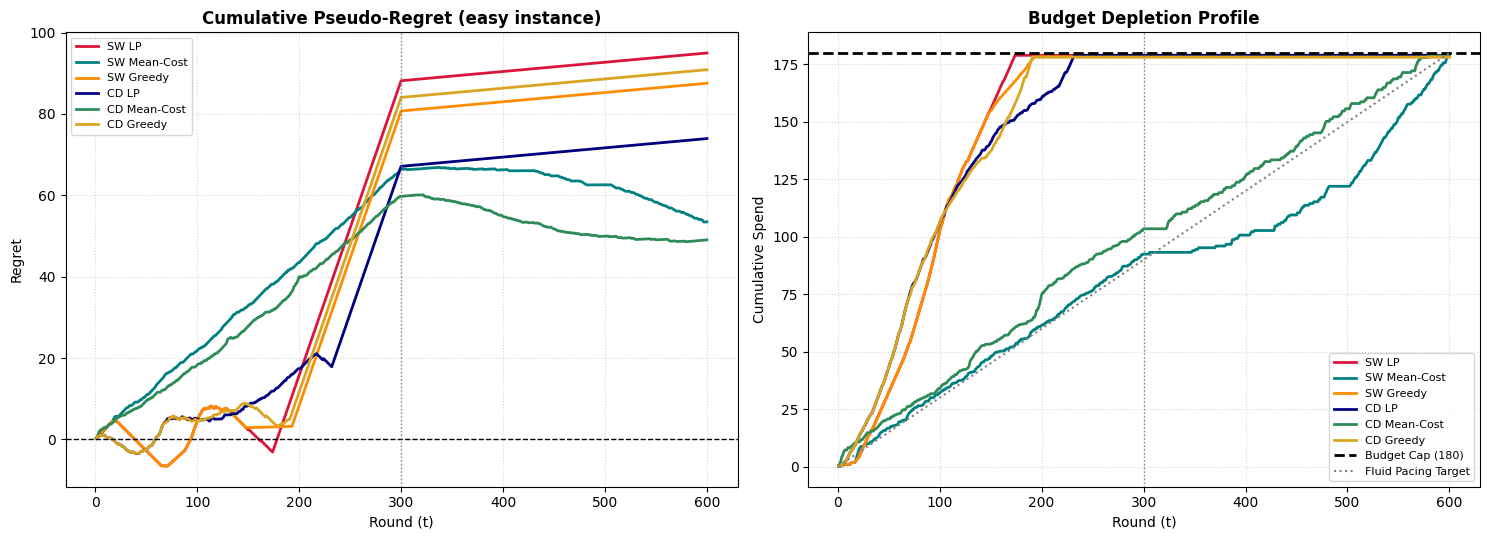


Agent            | Final Pseudo-Regret  | Final Spend     | n_resets  
---------------------------------------------------------------------------
SW LP            | 94.99                | 179.00/180.00      | -
SW Mean-Cost     | 53.48                | 178.75/180.00      | -
SW Greedy        | 87.56                | 178.25/180.00      | -
CD LP            | 73.95                | 179.00/180.00      | 1
CD Mean-Cost     | 49.06                | 178.75/180.00      | 3
CD Greedy        | 90.89                | 178.25/180.00      | 1


In [99]:
# ── EASY INSTANCE: 2 campaigns, no conflict, 1 breakpoint, dramatic shift ──
VALUES      = [1.0, 1.0]
BID_SPACE   = [0.0, 0.25, 0.5, 0.75, 1.0]
T           = 600
B           = 0.3 * T
W           = 60                          # sliding window size
CD_KWARGS   = dict(warmup=15, delta=0.05, lambda_th=3.0)   # change-detector params
CONFLICT    = [[False, False], [False, False]]
BREAKPOINTS = [0, 300]
SEED        = 1

CONFIGS = [
    {"means": [0.3, 0.3], "stds": [0.1, 0.1]},   # phase 0: easy, cheap wins
    {"means": [0.7, 0.7], "stds": [0.1, 0.1]},   # phase 1: hard, need higher bids
]

AGENTS_SPEC = {
    "SW LP":        (SW_LP_Agent,        dict(W=W)),
    "SW Mean-Cost": (SW_LP_MeanCost_Agent, dict(W=W)),
    "SW Greedy":    (SW_Greedy_Agent,    dict(W=W)),
    "CD LP":        (CD_LP_Agent,        CD_KWARGS),
    "CD Mean-Cost": (CD_LP_MeanCost_Agent, CD_KWARGS),
    "CD Greedy":    (CD_Greedy_Agent,    CD_KWARGS),
}
COLORS = {
    "SW LP": "crimson", "SW Mean-Cost": "teal", "SW Greedy": "darkorange",
    "CD LP": "navy",    "CD Mean-Cost": "seagreen", "CD Greedy": "goldenrod",
}


def make_env():
    return SlightlyNonStationaryMultiCampaignEnvironment(
        VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian',
        interval_configs=CONFIGS, seed=SEED
    )


if __name__ == "__main__":
    env_baseline = make_env()
    net_per_interval, cumulative_baseline, gammas, super_arms = compute_joint_piecewise_clairvoyant(env_baseline, BID_SPACE)
    print("Piecewise fluid OPT per interval:")
    for k in range(env_baseline.n_intervals):
        print(f"  interval {k} (t={env_baseline.starts[k]}-{env_baseline.ends[k]}): {net_per_interval[k]:.4f}/round")

    agents = {name: cls(VALUES, BID_SPACE, B, T, CONFLICT, **kwargs) for name, (cls, kwargs) in AGENTS_SPEC.items()}
    envs = {name: make_env() for name in agents}
    results = {name: {"expected_net": np.zeros(T), "spend": np.zeros(T)} for name in agents}

    print(f"\nSimulating T={T}...")
    for t in range(T):
        for name, agent in agents.items():
            bids = agent.pull_arm()
            won_vector, util_vector, cost_vector, info = envs[name].resolve_auction(bids)
            agent.update(won_vector, util_vector, cost_vector)
            results[name]["expected_net"][t] = info["expected_net"]
            results[name]["spend"][t] = envs[name].spent

    for name in agents:
        results[name]["pseudo_regret"] = cumulative_baseline - np.cumsum(results[name]["expected_net"])

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    rounds = np.arange(1, T + 1)

    for name in agents:
        axes[0].plot(rounds, results[name]["pseudo_regret"], color=COLORS[name], lw=2, label=name)
    axes[0].axhline(0, color='black', linestyle='--', lw=1)
    for bp in BREAKPOINTS[1:]:
        axes[0].axvline(bp, color='gray', linestyle=':', lw=1)
    axes[0].set_title("Cumulative Pseudo-Regret (easy instance)", fontweight='bold')
    axes[0].set_xlabel("Round (t)"); axes[0].set_ylabel("Regret")
    axes[0].legend(fontsize=8); axes[0].grid(True, linestyle=':', alpha=0.5)

    for name in agents:
        axes[1].plot(rounds, results[name]["spend"], color=COLORS[name], lw=2, label=name)
    axes[1].axhline(B, color='black', lw=2, linestyle='--', label=f"Budget Cap ({B:.0f})")
    axes[1].plot(rounds, (B / T) * rounds, color='gray', lw=1.5, linestyle=':', label="Fluid Pacing Target")
    for bp in BREAKPOINTS[1:]:
        axes[1].axvline(bp, color='gray', linestyle=':', lw=1)
    axes[1].set_title("Budget Depletion Profile", fontweight='bold')
    axes[1].set_xlabel("Round (t)"); axes[1].set_ylabel("Cumulative Spend")
    axes[1].legend(fontsize=8); axes[1].grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

    print(f"\n{'Agent':<16} | {'Final Pseudo-Regret':<20} | {'Final Spend':<15} | {'n_resets':<10}")
    print("-" * 75)
    for name in agents:
        n_resets = getattr(agents[name], 'n_resets', '-')
        print(f"{name:<16} | {results[name]['pseudo_regret'][-1]:<20.2f} | {results[name]['spend'][-1]:.2f}/{B:.2f}      | {n_resets}")

Piecewise fluid OPT per interval (joint-optimal budget allocation):
  interval 0 (t=0-500): 0.8413/round
  interval 1 (t=500-1000): 0.0013/round
  interval 2 (t=1000-1500): 0.5573/round
  interval 3 (t=1500-2000): 1.0000/round

Simulating T=2000...


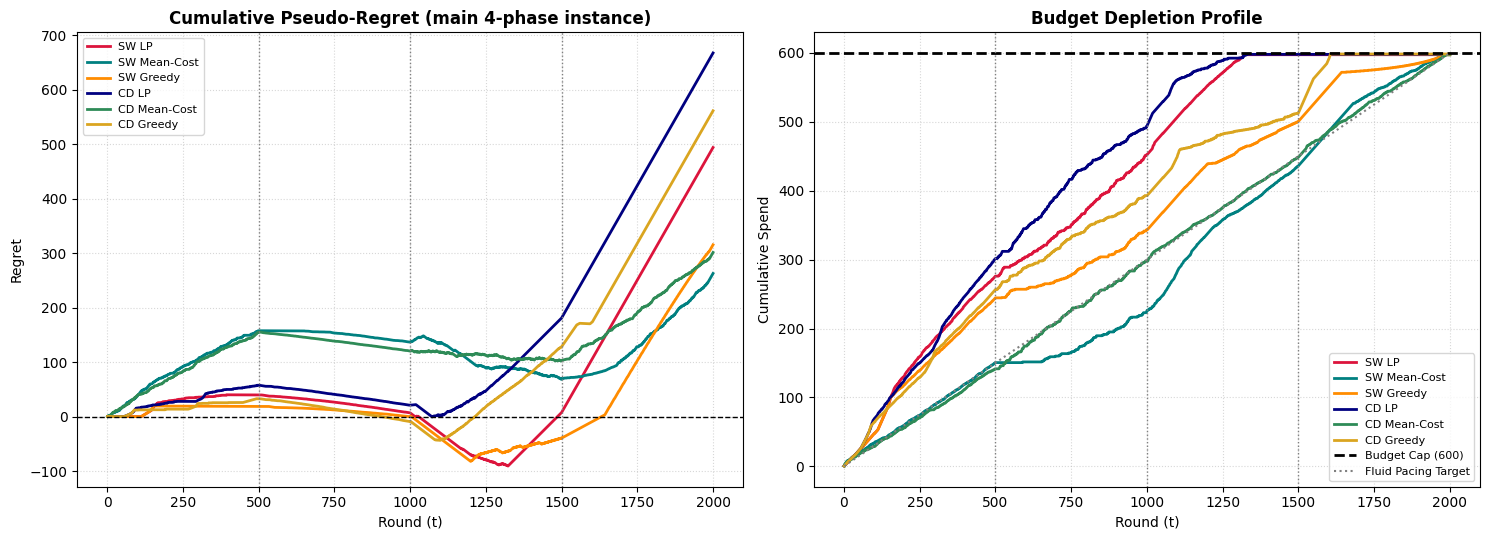


Agent            | Final Pseudo-Regret  | Final Spend     | n_resets  
---------------------------------------------------------------------------
SW LP            | 493.68               | 597.50/600.00      | -
SW Mean-Cost     | 262.52               | 597.50/600.00      | -
SW Greedy        | 315.16               | 597.50/600.00      | -
CD LP            | 667.14               | 598.00/600.00      | 3
CD Mean-Cost     | 301.10               | 597.50/600.00      | 3
CD Greedy        | 561.05               | 598.50/600.00      | 4


In [70]:
# ── MAIN INSTANCE: 2 campaigns, 1 conflicting pair, 4 phases, dramatic shifts ──
VALUES      = [1.5, 1.2]
BID_SPACE   = [0.0, 0.5, 1.0, 1.5]
T           = 2000
B           = 0.3 * T
W           = 200
CD_KWARGS   = dict(warmup=20, delta=0.08, lambda_th=6.0)
CONFLICT    = [[False, True], [True, False]]
BREAKPOINTS = [0, 500, 1000, 1500]
SEED        = 42   # np.random.seed() alone does NOT seed this env -- it uses default_rng

CONFIGS = [
    {"means": [0.4, 0.3], "stds": [0.1,  0.1 ]},   # phase 0: weak
    {"means": [1.1, 1.0], "stds": [0.2,  0.2 ]},   # phase 1: both strong (thin margins)
    {"means": [0.3, 1.2], "stds": [0.1,  0.2 ]},   # phase 2: campaign 1 dominant
    {"means": [0.2, 0.1], "stds": [0.05, 0.05]},   # phase 3: weak again
]

AGENTS_SPEC = {
    "SW LP":        (SW_LP_Agent,        dict(W=W)),
    "SW Mean-Cost": (SW_LP_MeanCost_Agent, dict(W=W)),
    "SW Greedy":    (SW_Greedy_Agent,    dict(W=W)),
    "CD LP":        (CD_LP_Agent,        CD_KWARGS),
    "CD Mean-Cost": (CD_LP_MeanCost_Agent, CD_KWARGS),
    "CD Greedy":    (CD_Greedy_Agent,    CD_KWARGS),
}
COLORS = {
    "SW LP": "crimson", "SW Mean-Cost": "teal", "SW Greedy": "darkorange",
    "CD LP": "navy",    "CD Mean-Cost": "seagreen", "CD Greedy": "goldenrod",
}


def make_env():
    return SlightlyNonStationaryMultiCampaignEnvironment(
        VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian',
        interval_configs=CONFIGS, seed=SEED
    )


if __name__ == "__main__":
    env_baseline = make_env()
    net_per_interval, cumulative_baseline, gammas, super_arms = compute_joint_piecewise_clairvoyant(env_baseline, BID_SPACE)
    print("Piecewise fluid OPT per interval (joint-optimal budget allocation):")
    for k in range(env_baseline.n_intervals):
        print(f"  interval {k} (t={env_baseline.starts[k]}-{env_baseline.ends[k]}): {net_per_interval[k]:.4f}/round")

    agents = {name: cls(VALUES, BID_SPACE, B, T, CONFLICT, **kwargs) for name, (cls, kwargs) in AGENTS_SPEC.items()}
    envs = {name: make_env() for name in agents}
    results = {name: {"expected_net": np.zeros(T), "spend": np.zeros(T)} for name in agents}

    print(f"\nSimulating T={T}...")
    for t in range(T):
        for name, agent in agents.items():
            bids = agent.pull_arm()
            won_vector, util_vector, cost_vector, info = envs[name].resolve_auction(bids)
            agent.update(won_vector, util_vector, cost_vector)
            results[name]["expected_net"][t] = info["expected_net"]
            results[name]["spend"][t] = envs[name].spent

    for name in agents:
        results[name]["pseudo_regret"] = cumulative_baseline - np.cumsum(results[name]["expected_net"])

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    rounds = np.arange(1, T + 1)

    for name in agents:
        axes[0].plot(rounds, results[name]["pseudo_regret"], color=COLORS[name], lw=2, label=name)
    axes[0].axhline(0, color='black', linestyle='--', lw=1)
    for bp in BREAKPOINTS[1:]:
        axes[0].axvline(bp, color='gray', linestyle=':', lw=1)
    axes[0].set_title("Cumulative Pseudo-Regret (main 4-phase instance)", fontweight='bold')
    axes[0].set_xlabel("Round (t)"); axes[0].set_ylabel("Regret")
    axes[0].legend(fontsize=8); axes[0].grid(True, linestyle=':', alpha=0.5)

    for name in agents:
        axes[1].plot(rounds, results[name]["spend"], color=COLORS[name], lw=2, label=name)
    axes[1].axhline(B, color='black', lw=2, linestyle='--', label=f"Budget Cap ({B:.0f})")
    axes[1].plot(rounds, (B / T) * rounds, color='gray', lw=1.5, linestyle=':', label="Fluid Pacing Target")
    for bp in BREAKPOINTS[1:]:
        axes[1].axvline(bp, color='gray', linestyle=':', lw=1)
    axes[1].set_title("Budget Depletion Profile", fontweight='bold')
    axes[1].set_xlabel("Round (t)"); axes[1].set_ylabel("Cumulative Spend")
    axes[1].legend(fontsize=8); axes[1].grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

    print(f"\n{'Agent':<16} | {'Final Pseudo-Regret':<20} | {'Final Spend':<15} | {'n_resets':<10}")
    print("-" * 75)
    for name in agents:
        n_resets = getattr(agents[name], 'n_resets', '-')
        print(f"{name:<16} | {results[name]['pseudo_regret'][-1]:<20.2f} | {results[name]['spend'][-1]:.2f}/{B:.2f}      | {n_resets}")

M = 64 valid super-arms
Piecewise fluid OPT per interval:
  interval 0 (t=0-600): 0.2961/round
  interval 1 (t=600-1200): 0.2550/round
  interval 2 (t=1200-1800): 0.9155/round
  interval 3 (t=1800-2400): 0.0967/round
  interval 4 (t=2400-3000): 0.2685/round
  interval 5 (t=3000-3600): 0.3192/round

Simulating T=3600...


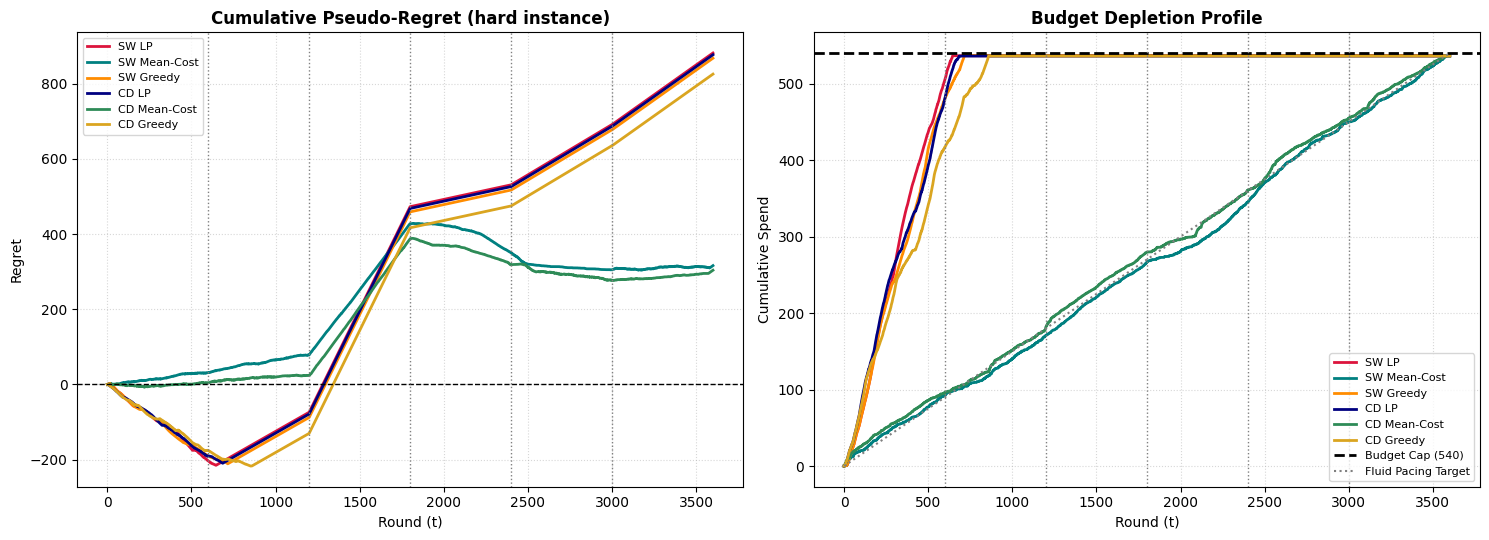


Agent            | Final Pseudo-Regret  | Final Spend     | n_resets  
---------------------------------------------------------------------------
SW LP            | 882.07               | 536.40/540.00      | -
SW Mean-Cost     | 316.28               | 536.20/540.00      | -
SW Greedy        | 868.23               | 536.80/540.00      | -
CD LP            | 877.39               | 536.00/540.00      | 1
CD Mean-Cost     | 304.04               | 536.20/540.00      | 5
CD Greedy        | 825.89               | 536.00/540.00      | 1


In [71]:
# ── HARD INSTANCE: 4 campaigns, triangle conflict, 6 SHORT phases, subtle shifts ──
VALUES      = [1.2, 1.0, 1.1, 0.6]
BID_SPACE   = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
T           = 3600
B           = 0.15 * T
W           = 250
# NOTE: more campaigns -> more (campaign,bid) trackers running in parallel ->
# false-alarm rate compounds faster (see the tuning discussion for the
# change detector). Threshold raised vs the main instance to compensate --
# retune further if you see many more resets than the 5 true breakpoints.
CD_KWARGS   = dict(warmup=25, delta=0.08, lambda_th=10.0)
CONFLICT    = [
    [False, True,  True,  False],
    [True,  False, True,  False],
    [True,  True,  False, False],
    [False, False, False, False],
]
BREAKPOINTS = [0, 600, 1200, 1800, 2400, 3000]
SEED        = 7

CONFIGS = [
    {"means": [0.35, 0.40, 0.30, 0.25], "stds": [0.08, 0.08, 0.08, 0.08]},
    {"means": [0.45, 0.35, 0.35, 0.30], "stds": [0.08, 0.08, 0.08, 0.08]},
    {"means": [0.30, 0.45, 0.40, 0.20], "stds": [0.08, 0.08, 0.08, 0.08]},
    {"means": [0.40, 0.30, 0.45, 0.35], "stds": [0.08, 0.08, 0.08, 0.08]},
    {"means": [0.25, 0.40, 0.30, 0.40], "stds": [0.08, 0.08, 0.08, 0.08]},
    {"means": [0.40, 0.25, 0.40, 0.25], "stds": [0.08, 0.08, 0.08, 0.08]},
]

AGENTS_SPEC = {
    "SW LP":        (SW_LP_Agent,        dict(W=W)),
    "SW Mean-Cost": (SW_LP_MeanCost_Agent, dict(W=W)),
    "SW Greedy":    (SW_Greedy_Agent,    dict(W=W)),
    "CD LP":        (CD_LP_Agent,        CD_KWARGS),
    "CD Mean-Cost": (CD_LP_MeanCost_Agent, CD_KWARGS),
    "CD Greedy":    (CD_Greedy_Agent,    CD_KWARGS),
}
COLORS = {
    "SW LP": "crimson", "SW Mean-Cost": "teal", "SW Greedy": "darkorange",
    "CD LP": "navy",    "CD Mean-Cost": "seagreen", "CD Greedy": "goldenrod",
}


def make_env():
    return SlightlyNonStationaryMultiCampaignEnvironment(
        VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian',
        interval_configs=CONFIGS, seed=SEED
    )


if __name__ == "__main__":
    env_baseline = make_env()
    net_per_interval, cumulative_baseline, gammas, super_arms = compute_joint_piecewise_clairvoyant(env_baseline, BID_SPACE)
    print(f"M = {len(super_arms)} valid super-arms")
    print("Piecewise fluid OPT per interval:")
    for k in range(env_baseline.n_intervals):
        print(f"  interval {k} (t={env_baseline.starts[k]}-{env_baseline.ends[k]}): {net_per_interval[k]:.4f}/round")

    agents = {name: cls(VALUES, BID_SPACE, B, T, CONFLICT, **kwargs) for name, (cls, kwargs) in AGENTS_SPEC.items()}
    envs = {name: make_env() for name in agents}
    results = {name: {"expected_net": np.zeros(T), "spend": np.zeros(T)} for name in agents}

    print(f"\nSimulating T={T}...")
    for t in range(T):
        for name, agent in agents.items():
            bids = agent.pull_arm()
            won_vector, util_vector, cost_vector, info = envs[name].resolve_auction(bids)
            agent.update(won_vector, util_vector, cost_vector)
            results[name]["expected_net"][t] = info["expected_net"]
            results[name]["spend"][t] = envs[name].spent

    for name in agents:
        results[name]["pseudo_regret"] = cumulative_baseline - np.cumsum(results[name]["expected_net"])

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    rounds = np.arange(1, T + 1)

    for name in agents:
        axes[0].plot(rounds, results[name]["pseudo_regret"], color=COLORS[name], lw=2, label=name)
    axes[0].axhline(0, color='black', linestyle='--', lw=1)
    for bp in BREAKPOINTS[1:]:
        axes[0].axvline(bp, color='gray', linestyle=':', lw=1)
    axes[0].set_title("Cumulative Pseudo-Regret (hard instance)", fontweight='bold')
    axes[0].set_xlabel("Round (t)"); axes[0].set_ylabel("Regret")
    axes[0].legend(fontsize=8); axes[0].grid(True, linestyle=':', alpha=0.5)

    for name in agents:
        axes[1].plot(rounds, results[name]["spend"], color=COLORS[name], lw=2, label=name)
    axes[1].axhline(B, color='black', lw=2, linestyle='--', label=f"Budget Cap ({B:.0f})")
    axes[1].plot(rounds, (B / T) * rounds, color='gray', lw=1.5, linestyle=':', label="Fluid Pacing Target")
    for bp in BREAKPOINTS[1:]:
        axes[1].axvline(bp, color='gray', linestyle=':', lw=1)
    axes[1].set_title("Budget Depletion Profile", fontweight='bold')
    axes[1].set_xlabel("Round (t)"); axes[1].set_ylabel("Cumulative Spend")
    axes[1].legend(fontsize=8); axes[1].grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

    print(f"\n{'Agent':<16} | {'Final Pseudo-Regret':<20} | {'Final Spend':<15} | {'n_resets':<10}")
    print("-" * 75)
    for name in agents:
        n_resets = getattr(agents[name], 'n_resets', '-')
        print(f"{name:<16} | {results[name]['pseudo_regret'][-1]:<20.2f} | {results[name]['spend'][-1]:.2f}/{B:.2f}      | {n_resets}")

we notice that the mean cost version of sw and cd work much better than the other learners. Therefore we mostly perform the next tests on these more interesting learners. 

## Primal-dual method

In [100]:
from src.req3_learners import PrimalDualMultiCampaignAgent, NSPrimalDualMultiCampaignAgent


Piecewise fluid OPT per interval (joint-optimal budget allocation):
  interval 0 (t=0-500): 0.8413/round
  interval 1 (t=500-1000): 0.0013/round
  interval 2 (t=1000-1500): 0.5573/round
  interval 3 (t=1500-2000): 1.0000/round

Executing Primal-Dual...
Final Regret: 228.37 | Final Spend: 600.00/600.00

Executing NS-Primal-Dual...
Final Regret: 266.16 | Final Spend: 600.00/600.00


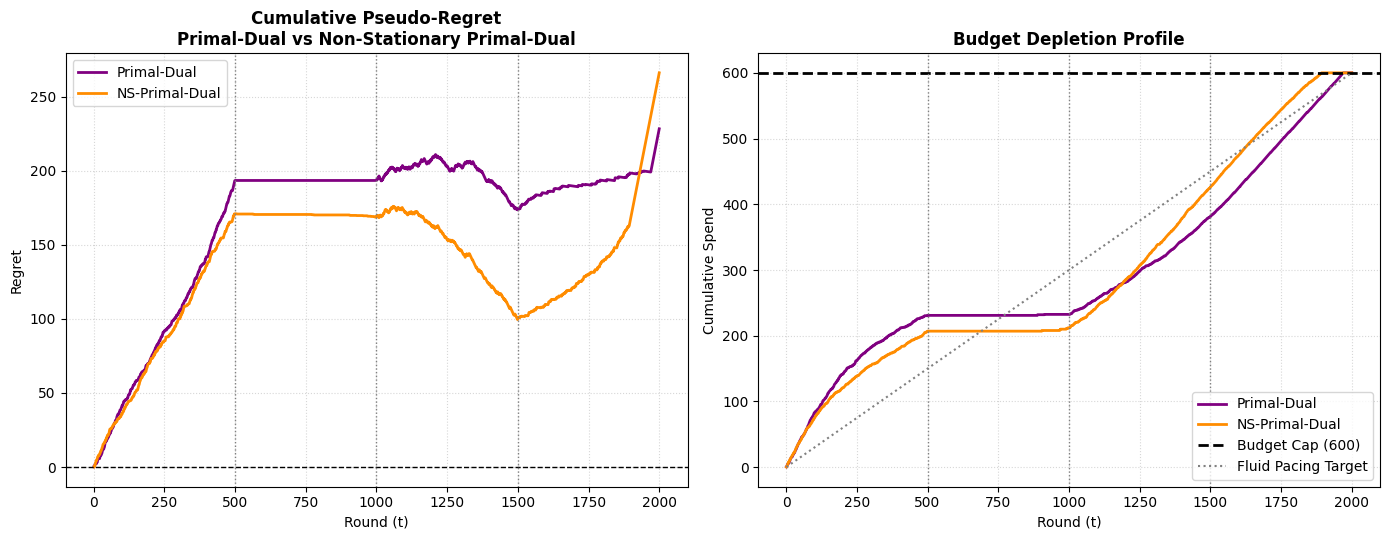

In [101]:
import numpy as np
import matplotlib.pyplot as plt

from src.req3_learners import PrimalDualMultiCampaignAgent, NSPrimalDualMultiCampaignAgent

VALUES      = [1.5, 1.2]
BID_SPACE   = [0.0, 0.5, 1.0, 1.5]
T           = 2000
B           = 0.3 * T
CONFLICT    = [[False, True], [True, False]]
BREAKPOINTS = [0, 500, 1000, 1500]
SEED        = 42

CONFIGS = [
    {"means": [0.4, 0.3], "stds": [0.1, 0.1]},
    {"means": [1.1, 1.0], "stds": [0.2, 0.2]},
    {"means": [0.3, 1.2], "stds": [0.1, 0.2]},
    {"means": [0.2, 0.1], "stds": [0.05, 0.05]},
]

# FIX: was 1.0 - 1.0/1000 with a comment claiming a 500-round memory window
# -- that arithmetic gives 1000, not 500 (1/(1-gamma) = 1/(1/1000) = 1000).
# Corrected to actually match the stated intent (500-round intervals).
GAMMA = 1.0 - 1.0 / 500

AGENT_CLASSES = {
    "Primal-Dual":    (PrimalDualMultiCampaignAgent, {}),
    "NS-Primal-Dual": (NSPrimalDualMultiCampaignAgent, dict(gamma=GAMMA)),
}
COLORS = {"Primal-Dual": "purple", "NS-Primal-Dual": "darkorange"}


def make_env():
    return SlightlyNonStationaryMultiCampaignEnvironment(
        VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian',
        interval_configs=CONFIGS, seed=SEED
    )


if __name__ == "__main__":
    # FIX: was compute_clairvoyant with a per-interval uniform B/T rate --
    # the buggy version that underestimates the true benchmark. Now uses
    # the joint budget-allocation-aware clairvoyant.
    env_baseline = make_env()
    net_per_interval, cumulative_baseline, gammas, super_arms = compute_joint_piecewise_clairvoyant(env_baseline, BID_SPACE)
    print("Piecewise fluid OPT per interval (joint-optimal budget allocation):")
    for k in range(env_baseline.n_intervals):
        print(f"  interval {k} (t={env_baseline.starts[k]}-{env_baseline.ends[k]}): {net_per_interval[k]:.4f}/round")

    agents = {name: cls(VALUES, BID_SPACE, B, T, CONFLICT, **kwargs) for name, (cls, kwargs) in AGENT_CLASSES.items()}
    envs = {name: make_env() for name in agents}
    results = {name: {"expected_net": np.zeros(T), "spend": np.zeros(T)} for name in agents}

    for name, agent in agents.items():
        print(f"\nExecuting {name}...")
        env = envs[name]
        for t in range(T):
            bids = agent.pull_arm()
            won, rew, cost, info = env.resolve_auction(bids)
            # full feedback for BOTH: valid per Req 3's explicit exception,
            # and both classes here are primal-dual variants that need it
            agent.update(won, rew, cost, info["m_t"])
            results[name]["expected_net"][t] = info["expected_net"]
            results[name]["spend"][t] = env.spent

        results[name]["pseudo_regret"] = cumulative_baseline - np.cumsum(results[name]["expected_net"])
        print(f"Final Regret: {results[name]['pseudo_regret'][-1]:.2f} | "
              f"Final Spend: {results[name]['spend'][-1]:.2f}/{B:.2f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    rounds = np.arange(1, T + 1)

    for name in agents:
        axes[0].plot(rounds, results[name]["pseudo_regret"], color=COLORS[name], lw=2, label=name)
    axes[0].axhline(0, color='black', linestyle='--', lw=1)
    for bp in BREAKPOINTS[1:]:
        axes[0].axvline(bp, color='gray', linestyle=':', lw=1)
    axes[0].set_title("Cumulative Pseudo-Regret\nPrimal-Dual vs Non-Stationary Primal-Dual", fontweight='bold')
    axes[0].set_xlabel("Round (t)"); axes[0].set_ylabel("Regret")
    axes[0].legend(); axes[0].grid(True, linestyle=':', alpha=0.5)

    for name in agents:
        axes[1].plot(rounds, results[name]["spend"], color=COLORS[name], lw=2, label=name)
    axes[1].axhline(B, color='black', lw=2, linestyle='--', label=f"Budget Cap ({B:.0f})")
    axes[1].plot(rounds, (B / T) * rounds, color='gray', lw=1.5, linestyle=':', label="Fluid Pacing Target")
    for bp in BREAKPOINTS[1:]:
        axes[1].axvline(bp, color='gray', linestyle=':', lw=1)
    axes[1].set_title("Budget Depletion Profile", fontweight='bold')
    axes[1].set_xlabel("Round (t)"); axes[1].set_ylabel("Cumulative Spend")
    axes[1].legend(); axes[1].grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

Piecewise fluid OPT per interval (joint-optimal budget allocation):
  interval 0 (t=0-500): 0.8413/round
  interval 1 (t=500-1000): 0.0013/round
  interval 2 (t=1000-1500): 0.5573/round
  interval 3 (t=1500-2000): 1.0000/round

Executing SW-LP-MeanCost...
Final Regret: 277.28 | Final Spend: 597.50/600.00 | n_resets: -

Executing CD-LP-MeanCost...
Final Regret: 295.69 | Final Spend: 597.50/600.00 | n_resets: 4

Executing Primal-Dual...
Final Regret: 255.49 | Final Spend: 600.00/600.00 | n_resets: -


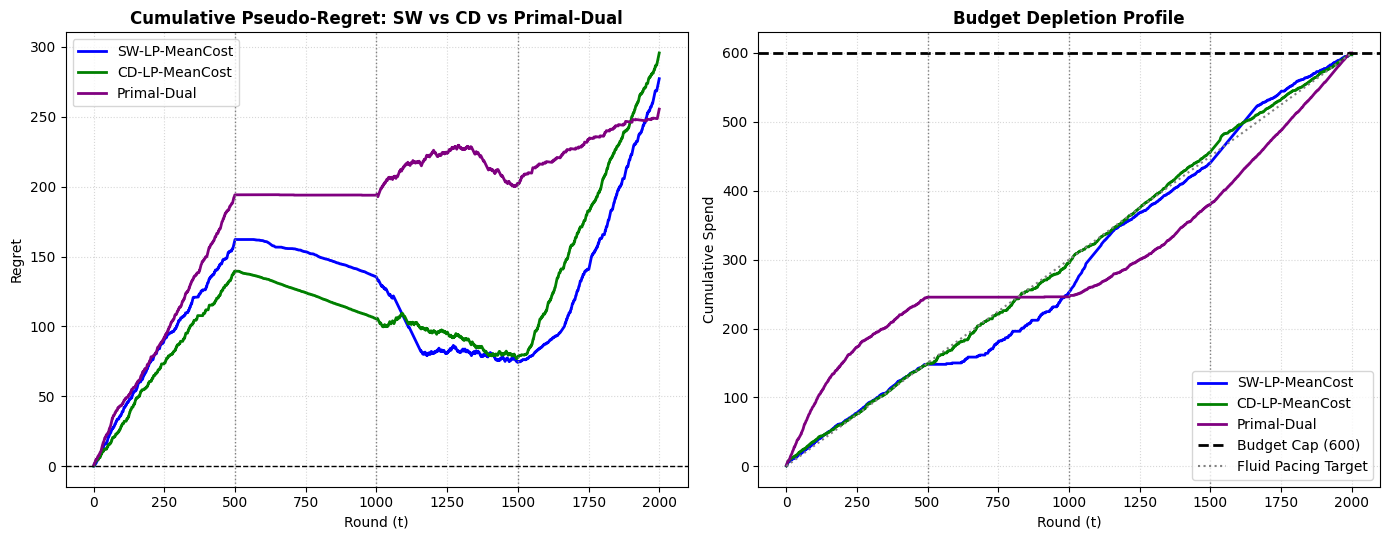

In [102]:
VALUES      = [1.5, 1.2]
BID_SPACE   = [0.0, 0.5, 1.0, 1.5]
T           = 2000
B           = 0.3 * T
CONFLICT    = [[False, True], [True, False]]
BREAKPOINTS = [0, 500, 1000, 1500]
SEED        = 42
W           = 200


CD_KWARGS   = dict(warmup=20, delta=0.08, lambda_th=6.0)

CONFIGS = [
    {"means": [0.4, 0.3], "stds": [0.1, 0.1]},
    {"means": [1.1, 1.0], "stds": [0.2, 0.2]},
    {"means": [0.3, 1.2], "stds": [0.1, 0.2]},
    {"means": [0.2, 0.1], "stds": [0.05, 0.05]},
]

AGENTS_SPEC = {
    "SW-LP-MeanCost": (SW_LP_MeanCost_Agent, dict(W=W)),
    "CD-LP-MeanCost": (CD_LP_MeanCost_Agent, CD_KWARGS),
    "Primal-Dual":    (PrimalDualMultiCampaignAgent, {}),
}
COLORS = {"SW-LP-MeanCost": "blue", "CD-LP-MeanCost": "green", "Primal-Dual": "purple"}
FULL_FEEDBACK_AGENTS = (PrimalDualMultiCampaignAgent,)  # only these get info["m_t"]


def make_env():
    return SlightlyNonStationaryMultiCampaignEnvironment(
        VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian',
        interval_configs=CONFIGS, seed=SEED
    )


if __name__ == "__main__":
    env_baseline = make_env()
    net_per_interval, cumulative_baseline, gammas, super_arms = compute_joint_piecewise_clairvoyant(env_baseline, BID_SPACE)
    print("Piecewise fluid OPT per interval (joint-optimal budget allocation):")
    for k in range(env_baseline.n_intervals):
        print(f"  interval {k} (t={env_baseline.starts[k]}-{env_baseline.ends[k]}): {net_per_interval[k]:.4f}/round")

    agents = {name: cls(VALUES, BID_SPACE, B, T, CONFLICT, **kwargs) for name, (cls, kwargs) in AGENTS_SPEC.items()}
    envs = {name: make_env() for name in agents}
    results = {name: {"expected_net": np.zeros(T), "spend": np.zeros(T)} for name in agents}

    for name, agent in agents.items():
        print(f"\nExecuting {name}...")
        env = envs[name]
        for t in range(T):
            bids = agent.pull_arm()
            won, rew, cost, info = env.resolve_auction(bids)
            if isinstance(agent, FULL_FEEDBACK_AGENTS):
                agent.update(won, rew, cost, info["m_t"])
            else:
                agent.update(won, rew, cost)
            results[name]["expected_net"][t] = info["expected_net"]
            results[name]["spend"][t] = env.spent

        results[name]["pseudo_regret"] = cumulative_baseline - np.cumsum(results[name]["expected_net"])
        n_resets = getattr(agent, 'n_resets', '-')
        print(f"Final Regret: {results[name]['pseudo_regret'][-1]:.2f} | "
              f"Final Spend: {results[name]['spend'][-1]:.2f}/{B:.2f} | n_resets: {n_resets}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    rounds = np.arange(1, T + 1)

    for name in agents:
        axes[0].plot(rounds, results[name]["pseudo_regret"], color=COLORS[name], lw=2, label=name)
    axes[0].axhline(0, color='black', linestyle='--', lw=1)
    for bp in BREAKPOINTS[1:]:
        axes[0].axvline(bp, color='gray', linestyle=':', lw=1)
    axes[0].set_title("Cumulative Pseudo-Regret: SW vs CD vs Primal-Dual", fontweight='bold')
    axes[0].set_xlabel("Round (t)"); axes[0].set_ylabel("Regret")
    axes[0].legend(); axes[0].grid(True, linestyle=':', alpha=0.5)

    for name in agents:
        axes[1].plot(rounds, results[name]["spend"], color=COLORS[name], lw=2, label=name)
    axes[1].axhline(B, color='black', lw=2, linestyle='--', label=f"Budget Cap ({B:.0f})")
    axes[1].plot(rounds, (B / T) * rounds, color='gray', lw=1.5, linestyle=':', label="Fluid Pacing Target")
    for bp in BREAKPOINTS[1:]:
        axes[1].axvline(bp, color='gray', linestyle=':', lw=1)
    axes[1].set_title("Budget Depletion Profile", fontweight='bold')
    axes[1].set_xlabel("Round (t)"); axes[1].set_ylabel("Cumulative Spend")
    axes[1].legend(); axes[1].grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

## Comparison of the performance of the three techniques : 

Completed 10/30 trials
Completed 20/30 trials
Completed 30/30 trials


NameError: name 'colors' is not defined

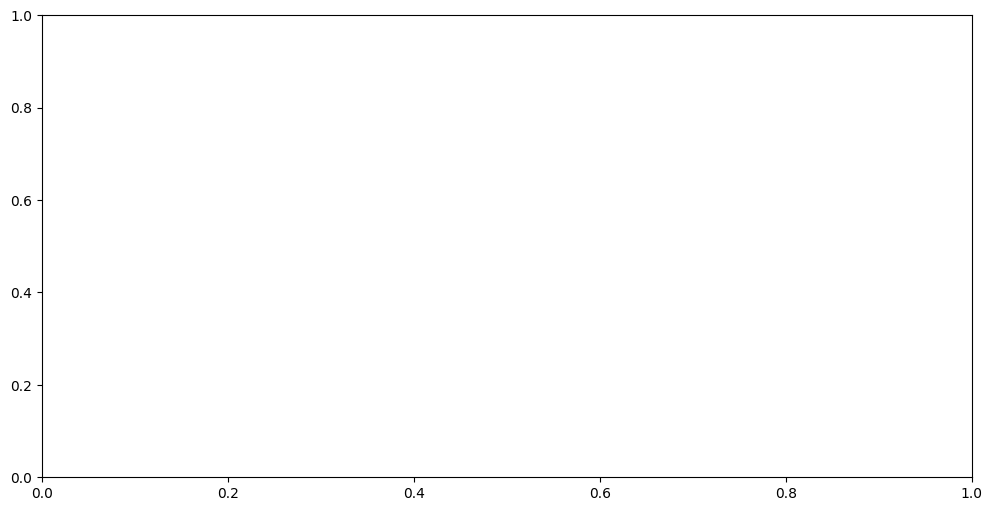

In [104]:
N_TRIALS = 30  # reduce if this is too slow on your machine

agent_factories = {
    "SW-LP-MeanCost": lambda: SW_LP_MeanCost_Agent(VALUES, BID_SPACE, B, T, CONFLICT, W),
    "CD-LP-MeanCost": lambda: CD_LP_MeanCost_Agent(VALUES, BID_SPACE, B, T, CONFLICT, delta=DELTA, lambda_th=LAMBDA_TH),
    "Primal-Dual":    lambda: PrimalDualMultiCampaignAgent(VALUES, BID_SPACE, B, T, CONFLICT),
}

all_regrets = {name: np.zeros((N_TRIALS, T)) for name in agent_factories}

for trial in range(N_TRIALS):
    for name, factory in agent_factories.items():
        np.random.seed(1000 + trial)  # common random numbers across agents, per trial
        agent = factory()
        env = SlightlyNonStationaryMultiCampaignEnvironment(
            VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian',
            interval_configs=configs, seed=2000 + trial  # varies ACROSS trials
        )

        regrets = np.zeros(T)
        for t in range(T):
            bids = agent.pull_arm()
            won, rew, cost, info = env.resolve_auction(bids)
            if isinstance(agent, FULL_FEEDBACK_AGENTS):
                agent.update(won, rew, cost, info["m_t"])
            else:
                agent.update(won, rew, cost)
            regrets[t] = opt_nets[info["interval"]] - info["expected_net"]

        all_regrets[name][trial] = np.cumsum(regrets)

    if (trial + 1) % 10 == 0:
        print(f"Completed {trial + 1}/{N_TRIALS} trials")


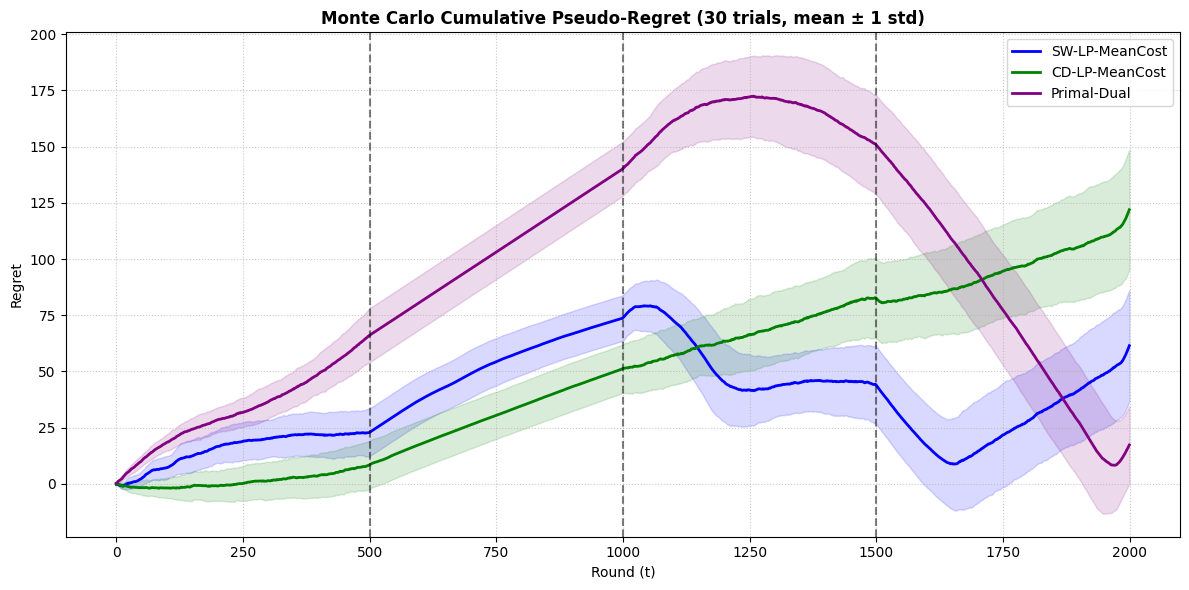

In [105]:
    fig, ax = plt.subplots(figsize=(12, 6))
    for name, regret_matrix in all_regrets.items():
        mean_curve = regret_matrix.mean(axis=0)
        std_curve = regret_matrix.std(axis=0)
        ax.plot(mean_curve, label=name, color=COLORS[name], lw=2)
        ax.fill_between(np.arange(T), mean_curve - std_curve, mean_curve + std_curve,
                         color=COLORS[name], alpha=0.15)
    for bp in BREAKPOINTS[1:]:
        ax.axvline(bp, color='black', linestyle='--', alpha=0.5)
    ax.set_title(f'Monte Carlo Cumulative Pseudo-Regret ({N_TRIALS} trials, mean ± 1 std)', fontweight='bold')
    ax.set_xlabel('Round (t)'); ax.set_ylabel('Regret')
    ax.legend(); ax.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()
 

Pre-computing dynamic baselines (N=4 campaigns)...
M = 24 valid super-arms
  interval 0 (t=0-500): OPT = 0.8413/round
  interval 1 (t=500-1000): OPT = 0.0013/round
  interval 2 (t=1000-1500): OPT = 0.5573/round
  interval 3 (t=1500-2000): OPT = 1.0000/round

Executing SW-LP-MeanCost...
Final Regret: 308.11 | Final Utility: 899.20 | Final Spend: 594.50/600.00 | n_resets: -

Executing CD-LP-MeanCost...
Final Regret: 336.52 | Final Utility: 872.20 | Final Spend: 594.50/600.00 | n_resets: 4

Executing Primal-Dual...
Final Regret: 566.63 | Final Utility: 642.00 | Final Spend: 600.50/600.00 | n_resets: -


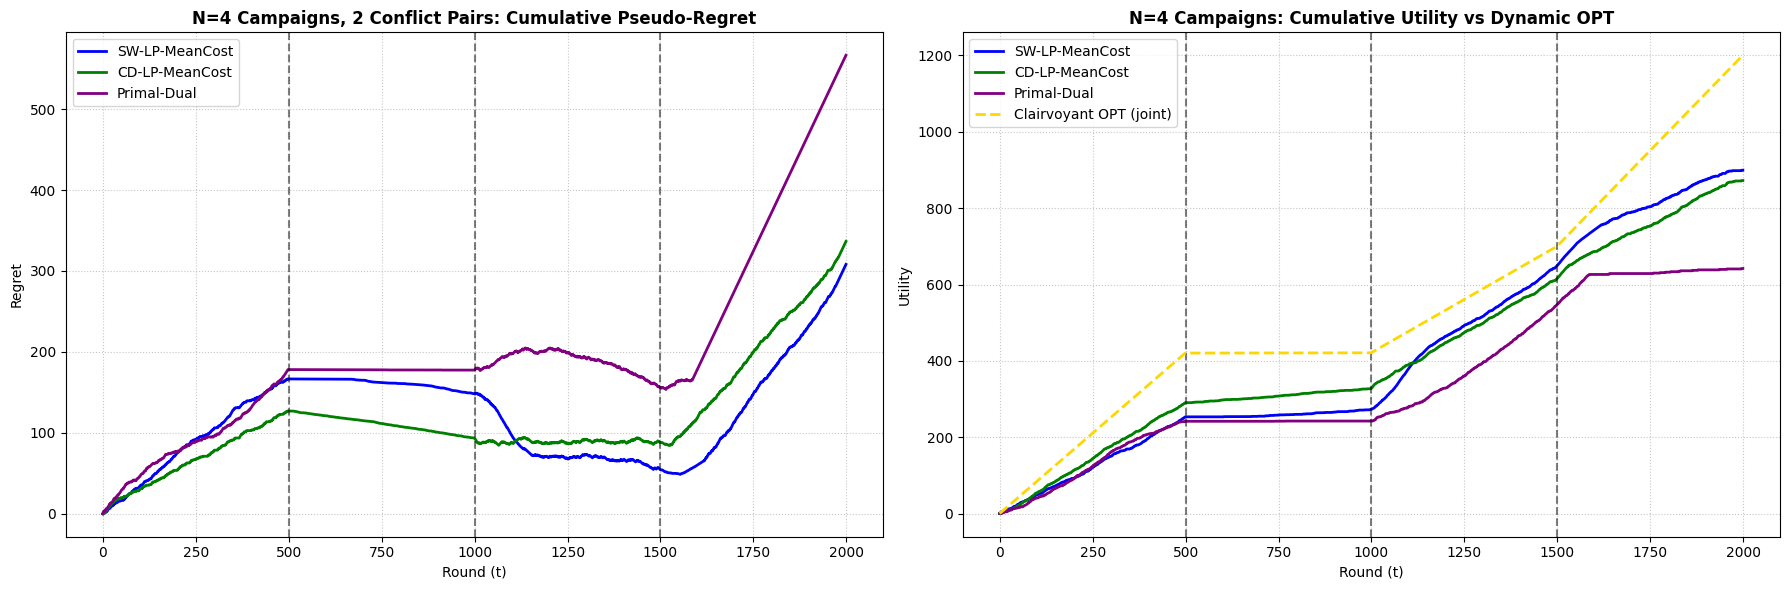

In [106]:

VALUES      = [1.5, 1.2, 1.0, 0.8]
BID_SPACE   = [0.0, 0.5, 1.0, 1.5]
T           = 2000
B           = 0.3 * T
# Two independent conflict pairs: (0,1) compete, (2,3) compete, no cross-pair conflict
CONFLICT = [
    [False, True,  False, False],
    [True,  False, False, False],
    [False, False, False, True ],
    [False, False, True,  False],
]
BREAKPOINTS = [0, 500, 1000, 1500]
SEED        = 101
W           = 200
# well-tuned CD baseline, same reasoning as the other two sweeps
CD_KWARGS   = dict(warmup=20, delta=0.08, lambda_th=6.0)

CONFIGS = [
    {"means": [0.4, 0.3, 0.5, 0.35], "stds": [0.10, 0.10, 0.10, 0.10]},
    {"means": [1.1, 1.0, 0.9, 0.70], "stds": [0.20, 0.20, 0.15, 0.15]},
    {"means": [0.3, 1.2, 0.4, 0.90], "stds": [0.10, 0.20, 0.10, 0.15]},
    {"means": [0.2, 0.1, 0.3, 0.15], "stds": [0.05, 0.05, 0.05, 0.05]},
]

FULL_FEEDBACK_AGENTS = (PrimalDualMultiCampaignAgent,)
COLORS = {'SW-LP-MeanCost': 'blue', 'CD-LP-MeanCost': 'green', 'Primal-Dual': 'purple'}


def make_env():
    return SlightlyNonStationaryMultiCampaignEnvironment(
        VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian',
        interval_configs=CONFIGS, seed=SEED
    )


if __name__ == "__main__":
    print("Pre-computing dynamic baselines (N=4 campaigns)...")
    env_baseline = make_env()
    net_per_interval, cumulative_baseline, gammas, super_arms = compute_joint_piecewise_clairvoyant(env_baseline, BID_SPACE)
    print(f"M = {len(super_arms)} valid super-arms")
    for k in range(env_baseline.n_intervals):
        print(f"  interval {k} (t={env_baseline.starts[k]}-{env_baseline.ends[k]}): OPT = {net_per_interval[k]:.4f}/round")

    agents = {
        "SW-LP-MeanCost": SW_LP_MeanCost_Agent(VALUES, BID_SPACE, B, T, CONFLICT, W),
        "CD-LP-MeanCost": CD_LP_MeanCost_Agent(VALUES, BID_SPACE, B, T, CONFLICT, **CD_KWARGS),
        "Primal-Dual":    PrimalDualMultiCampaignAgent(VALUES, BID_SPACE, B, T, CONFLICT),
    }

    results = {}
    for name, agent in agents.items():
        print(f"\nExecuting {name}...")
        env = make_env()      # same seed -> common random numbers across agents
        np.random.seed(42)    # matched RNG start for each agent's own sampling

        expected_net, utilities = np.zeros(T), np.zeros(T)
        for t in range(T):
            bids = agent.pull_arm()
            won, rew, cost, info = env.resolve_auction(bids)
            if isinstance(agent, FULL_FEEDBACK_AGENTS):
                agent.update(won, rew, cost, info["m_t"])
            else:
                agent.update(won, rew, cost)
            expected_net[t] = info["expected_net"]
            utilities[t] = np.sum(rew)

        results[name] = {
            "cum_regret": cumulative_baseline - np.cumsum(expected_net),
            "cum_utility": np.cumsum(utilities),
            "spend": env.spent,
        }
        n_resets = getattr(agent, 'n_resets', '-')
        print(f"Final Regret: {results[name]['cum_regret'][-1]:.2f} | "
              f"Final Utility: {results[name]['cum_utility'][-1]:.2f} | "
              f"Final Spend: {env.spent:.2f}/{B:.2f} | n_resets: {n_resets}")

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    for name, data in results.items():
        axes[0].plot(data['cum_regret'], label=name, color=COLORS[name], lw=2)
    for bp in BREAKPOINTS[1:]:
        axes[0].axvline(bp, color='black', linestyle='--', alpha=0.5)
    axes[0].set_title('N=4 Campaigns, 2 Conflict Pairs: Cumulative Pseudo-Regret', fontweight='bold')
    axes[0].set_xlabel('Round (t)'); axes[0].set_ylabel('Regret')
    axes[0].legend(); axes[0].grid(True, linestyle=':', alpha=0.7)

    for name, data in results.items():
        axes[1].plot(data['cum_utility'], label=name, color=COLORS[name], lw=2)
    for bp in BREAKPOINTS[1:]:
        axes[1].axvline(bp, color='black', linestyle='--', alpha=0.5)
    axes[1].plot(cumulative_baseline, label='Clairvoyant OPT (joint)', color='gold', linestyle='--', lw=2)
    axes[1].set_title('N=4 Campaigns: Cumulative Utility vs Dynamic OPT', fontweight='bold')
    axes[1].set_xlabel('Round (t)'); axes[1].set_ylabel('Utility')
    axes[1].legend(); axes[1].grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.show()


=== Budget ratio rho = 0.10  (B=200.0) ===
  SW-LP-MeanCost   Final Regret:   66.29 | Final Spend: 197.50/200.00 | n_resets: -
  CD-LP-MeanCost   Final Regret:  104.04 | Final Spend: 197.50/200.00 | n_resets: 4
  Primal-Dual      Final Regret:  280.45 | Final Spend: 200.50/200.00 | n_resets: -

=== Budget ratio rho = 0.20  (B=400.0) ===
  SW-LP-MeanCost   Final Regret:  148.02 | Final Spend: 397.50/400.00 | n_resets: -
  CD-LP-MeanCost   Final Regret:  221.80 | Final Spend: 397.50/400.00 | n_resets: 4
  Primal-Dual      Final Regret:  284.22 | Final Spend: 400.00/400.00 | n_resets: -

=== Budget ratio rho = 0.30  (B=600.0) ===
  SW-LP-MeanCost   Final Regret:  284.85 | Final Spend: 597.50/600.00 | n_resets: -
  CD-LP-MeanCost   Final Regret:  251.23 | Final Spend: 597.50/600.00 | n_resets: 3
  Primal-Dual      Final Regret:  251.81 | Final Spend: 600.00/600.00 | n_resets: -

=== Budget ratio rho = 0.50  (B=1000.0) ===
  SW-LP-MeanCost   Final Regret:  227.55 | Final Spend: 997.50/1000

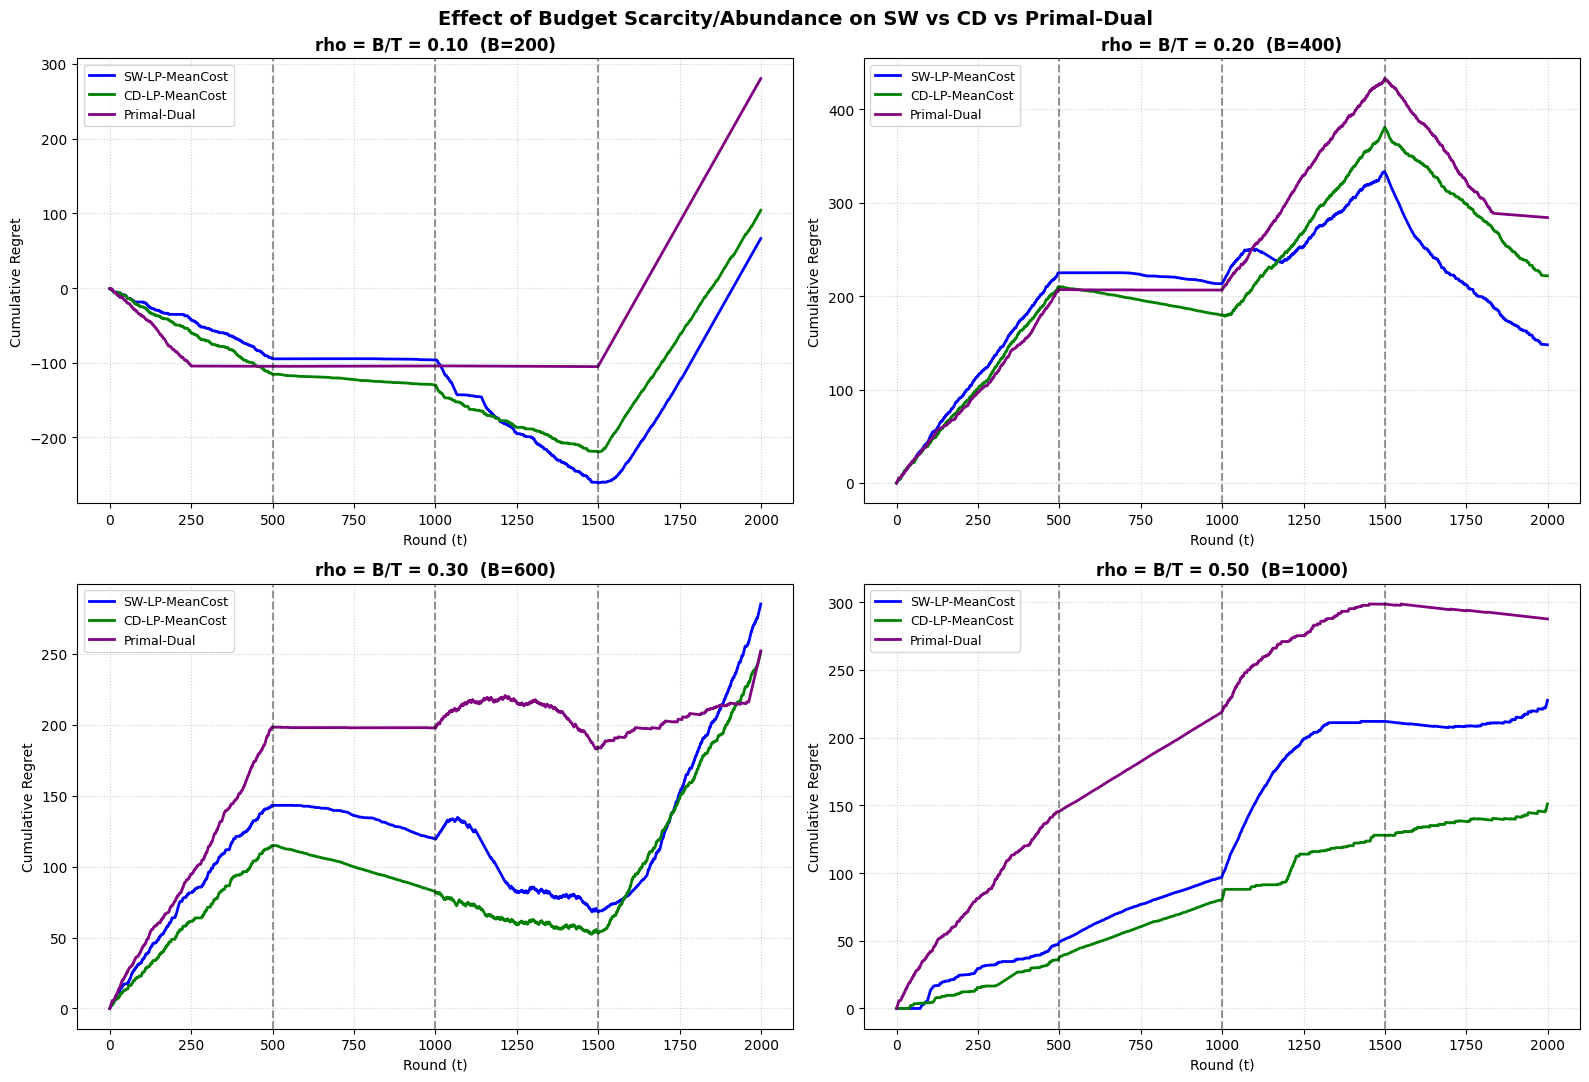

In [77]:

VALUES      = [1.5, 1.2]
BID_SPACE   = [0.0, 0.5, 1.0, 1.5]
T           = 2000
CONFLICT    = [[False, True], [True, False]]
BREAKPOINTS = [0, 500, 1000, 1500]
SEED        = 101
W           = 200

CD_KWARGS   = dict(warmup=20, delta=0.08, lambda_th=6.0)

CONFIGS = [
    {"means": [0.4, 0.3], "stds": [0.1, 0.1]},
    {"means": [1.1, 1.0], "stds": [0.2, 0.2]},
    {"means": [0.3, 1.2], "stds": [0.1, 0.2]},
    {"means": [0.2, 0.1], "stds": [0.05, 0.05]},
]

BUDGET_RATIOS = [0.10, 0.20, 0.30, 0.50]   # B = ratio * T; 0.30 is your original baseline
FULL_FEEDBACK_AGENTS = (PrimalDualMultiCampaignAgent,)
COLORS = {'SW-LP-MeanCost': 'blue', 'CD-LP-MeanCost': 'green', 'Primal-Dual': 'purple'}


def make_env(B):
    return SlightlyNonStationaryMultiCampaignEnvironment(
        VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian',
        interval_configs=CONFIGS, seed=SEED
    )


if __name__ == "__main__":
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    axes = axes.flatten()

    for ax_idx, ratio in enumerate(BUDGET_RATIOS):
        B = ratio * T
        print(f"\n=== Budget ratio rho = {ratio:.2f}  (B={B:.1f}) ===")

        env_baseline = make_env(B)
        net_per_interval, cumulative_baseline, gammas, super_arms = compute_joint_piecewise_clairvoyant(env_baseline, BID_SPACE)

        agents = {
            "SW-LP-MeanCost": SW_LP_MeanCost_Agent(VALUES, BID_SPACE, B, T, CONFLICT, W),
            "CD-LP-MeanCost": CD_LP_MeanCost_Agent(VALUES, BID_SPACE, B, T, CONFLICT, **CD_KWARGS),
            "Primal-Dual":    PrimalDualMultiCampaignAgent(VALUES, BID_SPACE, B, T, CONFLICT),
        }

        ax = axes[ax_idx]
        for name, agent in agents.items():
            env = make_env(B)          # same seed -> common random numbers across agents
            np.random.seed(42)         # matched RNG start for each agent's own sampling

            expected_net = np.zeros(T)
            for t in range(T):
                bids = agent.pull_arm()
                won, rew, cost, info = env.resolve_auction(bids)
                if isinstance(agent, FULL_FEEDBACK_AGENTS):
                    agent.update(won, rew, cost, info["m_t"])
                else:
                    agent.update(won, rew, cost)
                expected_net[t] = info["expected_net"]

            cum_regret = cumulative_baseline - np.cumsum(expected_net)
            ax.plot(cum_regret, label=name, color=COLORS[name], lw=2)

            n_resets = getattr(agent, 'n_resets', '-')
            print(f"  {name:<16} Final Regret: {cum_regret[-1]:7.2f} | Final Spend: {env.spent:.2f}/{B:.2f} | n_resets: {n_resets}")

        for bp in BREAKPOINTS[1:]:
            ax.axvline(bp, color='black', linestyle='--', alpha=0.4)
        ax.set_title(f'rho = B/T = {ratio:.2f}  (B={B:.0f})', fontweight='bold')
        ax.set_xlabel('Round (t)'); ax.set_ylabel('Cumulative Regret')
        ax.legend(fontsize=9); ax.grid(True, linestyle=':', alpha=0.6)

    fig.suptitle('Effect of Budget Scarcity/Abundance on SW vs CD vs Primal-Dual', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


=== T = 1000  (B=300.0, breakpoints=[0, 250, 500, 750]) ===
  SW-LP-MeanCost   Final Regret:  152.79 | Final Spend: 297.50/300.00 | n_resets: -
  CD-LP-MeanCost   Final Regret:  167.59 | Final Spend: 297.50/300.00 | n_resets: 3
  Primal-Dual      Final Regret:  181.28 | Final Spend: 300.00/300.00 | n_resets: -

=== T = 2000  (B=600.0, breakpoints=[0, 500, 1000, 1500]) ===
  SW-LP-MeanCost   Final Regret:  284.85 | Final Spend: 597.50/600.00 | n_resets: -
  CD-LP-MeanCost   Final Regret:  251.23 | Final Spend: 597.50/600.00 | n_resets: 3
  Primal-Dual      Final Regret:  251.81 | Final Spend: 600.00/600.00 | n_resets: -

=== T = 4000  (B=1200.0, breakpoints=[0, 1000, 2000, 3000]) ===
  SW-LP-MeanCost   Final Regret:  513.87 | Final Spend: 1197.50/1200.00 | n_resets: -
  CD-LP-MeanCost   Final Regret:  515.09 | Final Spend: 1197.50/1200.00 | n_resets: 3
  Primal-Dual      Final Regret:  468.09 | Final Spend: 1139.00/1200.00 | n_resets: -

=== T = 8000  (B=2400.0, breakpoints=[0, 2000, 4

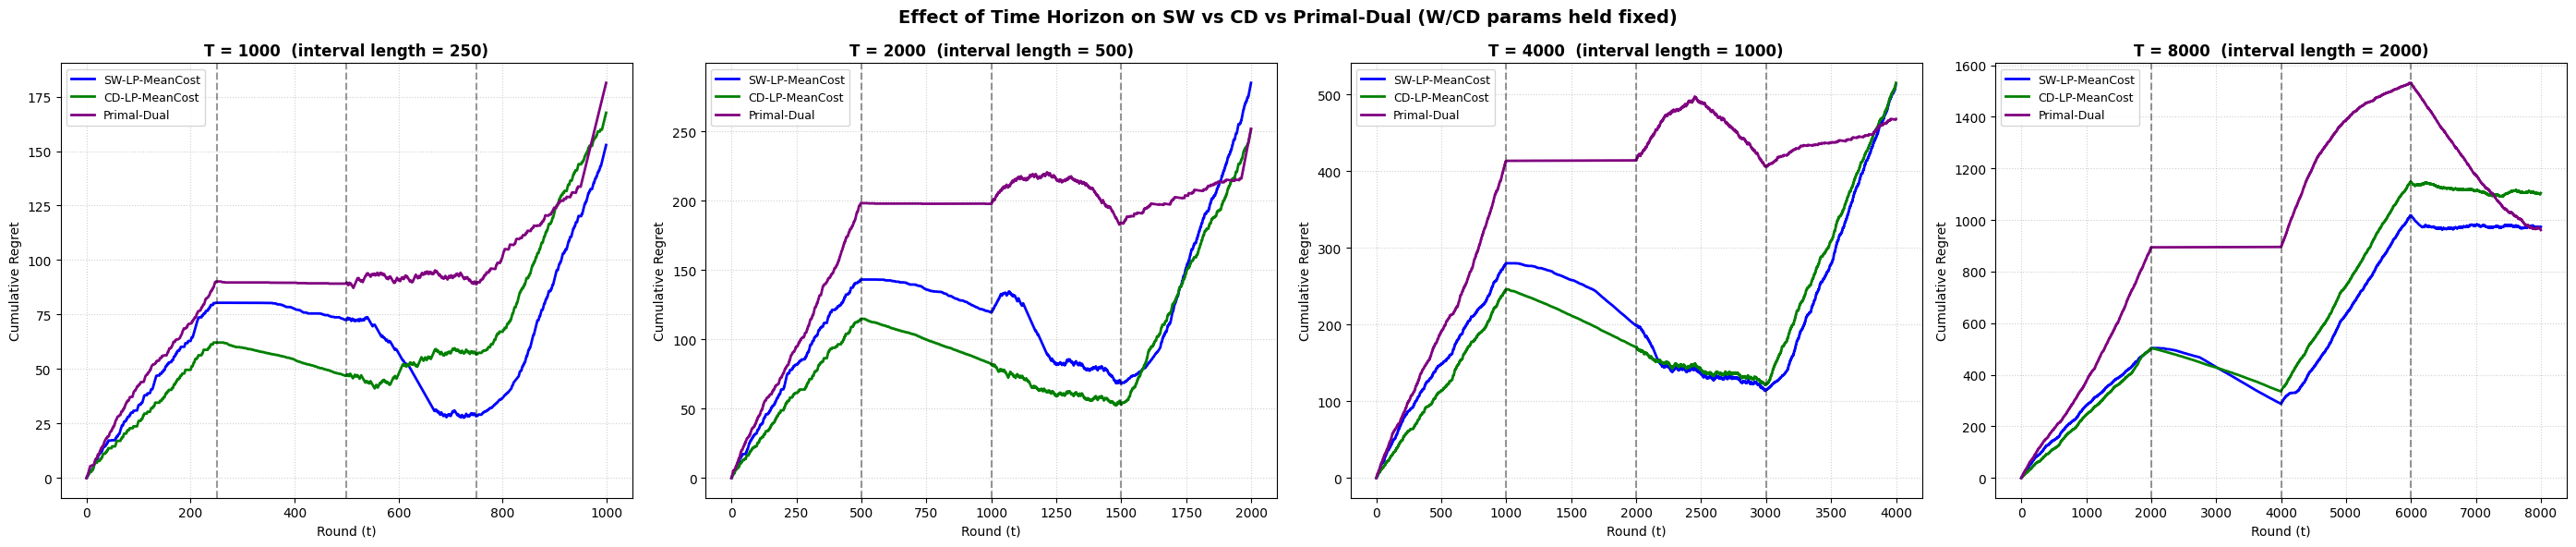

In [76]:

VALUES    = [1.5, 1.2]
BID_SPACE = [0.0, 0.5, 1.0, 1.5]
CONFLICT  = [[False, True], [True, False]]
RHO = 0.3   # budget ratio held fixed; B = RHO * T at every horizon

# W, and the CD parameters, are held fixed across the sweep .

W = 200
CD_KWARGS = dict(warmup=20, delta=0.08, lambda_th=6.0)

CONFIGS = [
    {"means": [0.4, 0.3], "stds": [0.1, 0.1]},
    {"means": [1.1, 1.0], "stds": [0.2, 0.2]},
    {"means": [0.3, 1.2], "stds": [0.1, 0.2]},
    {"means": [0.2, 0.1], "stds": [0.05, 0.05]},
]

T_VALUES = [1000, 2000, 4000, 8000]   # 2000 is your original baseline
FULL_FEEDBACK_AGENTS = (PrimalDualMultiCampaignAgent,)
COLORS = {'SW-LP-MeanCost': 'blue', 'CD-LP-MeanCost': 'green', 'Primal-Dual': 'purple'}
SEED = 101


def make_env(T, B, breakpoints):
    return SlightlyNonStationaryMultiCampaignEnvironment(
        VALUES, B, T, CONFLICT, breakpoints, dist_type='gaussian',
        interval_configs=CONFIGS, seed=SEED
    )


if __name__ == "__main__":
    fig, axes = plt.subplots(1, len(T_VALUES), figsize=(7 * len(T_VALUES), 6))

    for ax_idx, T in enumerate(T_VALUES):
        B = RHO * T
        BREAKPOINTS = [int(f * T) for f in (0, 0.25, 0.5, 0.75)]
        print(f"\n=== T = {T}  (B={B:.1f}, breakpoints={BREAKPOINTS}) ===")

        env_baseline = make_env(T, B, BREAKPOINTS)
        net_per_interval, cumulative_baseline, gammas, super_arms = compute_joint_piecewise_clairvoyant(env_baseline, BID_SPACE)

        agents = {
            "SW-LP-MeanCost": SW_LP_MeanCost_Agent(VALUES, BID_SPACE, B, T, CONFLICT, W),
            "CD-LP-MeanCost": CD_LP_MeanCost_Agent(VALUES, BID_SPACE, B, T, CONFLICT, **CD_KWARGS),
            "Primal-Dual":    PrimalDualMultiCampaignAgent(VALUES, BID_SPACE, B, T, CONFLICT),
        }

        ax = axes[ax_idx]
        for name, agent in agents.items():
            env = make_env(T, B, BREAKPOINTS)   
            np.random.seed(42)                  

            expected_net = np.zeros(T)
            for t in range(T):
                bids = agent.pull_arm()
                won, rew, cost, info = env.resolve_auction(bids)
                if isinstance(agent, FULL_FEEDBACK_AGENTS):
                    agent.update(won, rew, cost, info["m_t"])
                else:
                    agent.update(won, rew, cost)
                expected_net[t] = info["expected_net"]

            cum_regret = cumulative_baseline - np.cumsum(expected_net)
            ax.plot(cum_regret, label=name, color=COLORS[name], lw=2)

            n_resets = getattr(agent, 'n_resets', '-')
            print(f"  {name:<16} Final Regret: {cum_regret[-1]:7.2f} | Final Spend: {env.spent:.2f}/{B:.2f} | n_resets: {n_resets}")

        for bp in BREAKPOINTS[1:]:
            ax.axvline(bp, color='black', linestyle='--', alpha=0.4)
        ax.set_title(f'T = {T}  (interval length = {T // 4})', fontweight='bold')
        ax.set_xlabel('Round (t)'); ax.set_ylabel('Cumulative Regret')
        ax.legend(fontsize=9); ax.grid(True, linestyle=':', alpha=0.6)

    fig.suptitle('Effect of Time Horizon on SW vs CD vs Primal-Dual (W/CD params held fixed)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

M = 25 valid super-arms
Piecewise fluid OPT per interval:
  interval 0 (t=0-500): 1.1010/round
  interval 1 (t=500-1000): 0.1330/round


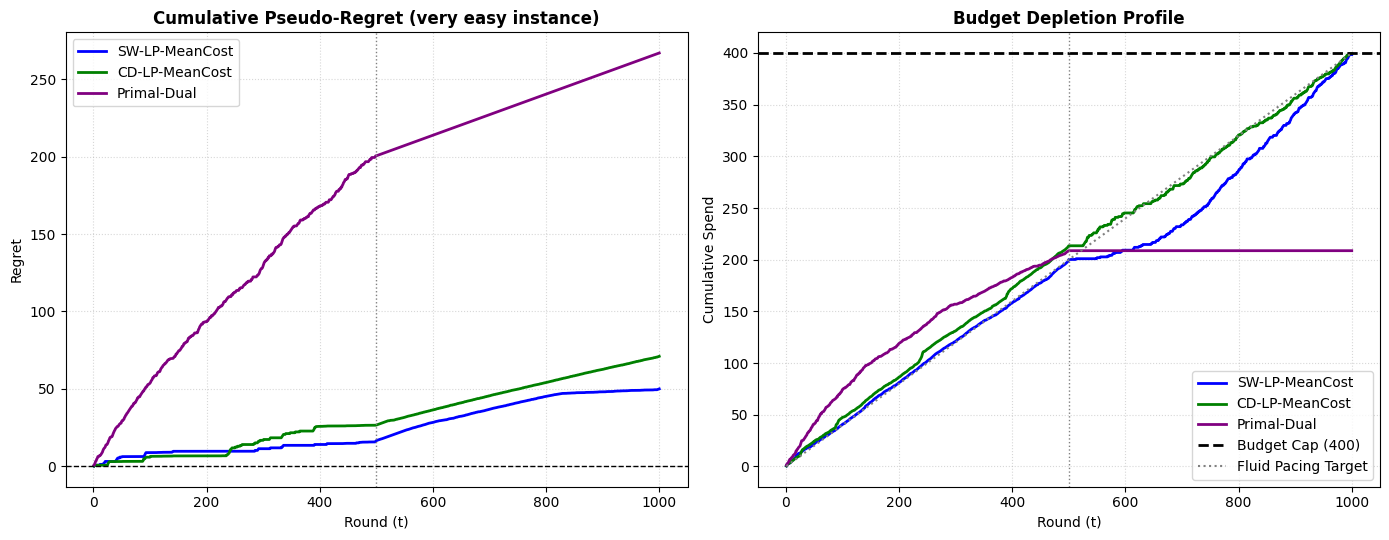


Agent            | Final Pseudo-Regret  | Final Spend     | n_resets  
---------------------------------------------------------------------------
SW-LP-MeanCost   | 49.91                | 398.50/400.00      | -
CD-LP-MeanCost   | 70.98                | 399.50/400.00      | 4
Primal-Dual      | 267.13               | 208.75/400.00      | -


In [84]:

# ══════════════════════════════════════════════════════════════════════════
# VERY EASY INSTANCE
# 2 campaigns, no conflicts, ONE breakpoint, dramatic and obvious shift
# (0.2 -> 0.8), generous budget. If any agent struggles here, something is
# actually wrong -- good as a basic correctness sanity check before trusting
# results on harder instances.
# ══════════════════════════════════════════════════════════════════════════
VALUES      = [1.0, 1.0]
BID_SPACE   = [0.0, 0.25, 0.5, 0.75, 1.0]
T           = 1000
B           = 0.4 * T
CONFLICT    = [[False, False], [False, False]]
BREAKPOINTS = [0, 500]
SEED        = 1
W           = 100
CD_KWARGS   = dict(warmup=15, delta=0.08, lambda_th=4.0)

CONFIGS = [
    {"means": [0.2, 0.2], "stds": [0.08, 0.08]},   # easy: cheap wins
    {"means": [0.8, 0.8], "stds": [0.08, 0.08]},   # hard: need high bids
]

AGENTS_SPEC = {
    "SW-LP-MeanCost": (SW_LP_MeanCost_Agent, dict(W=W)),
    "CD-LP-MeanCost": (CD_LP_MeanCost_Agent, CD_KWARGS),
    "Primal-Dual":    (PrimalDualMultiCampaignAgent, {}),
}
COLORS = {"SW-LP-MeanCost": "blue", "CD-LP-MeanCost": "green", "Primal-Dual": "purple"}
FULL_FEEDBACK_AGENTS = (PrimalDualMultiCampaignAgent,)


def make_env():
    return SlightlyNonStationaryMultiCampaignEnvironment(
        VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian',
        interval_configs=CONFIGS, seed=SEED
    )


if __name__ == "__main__":
    env_baseline = make_env()
    net_per_interval, cumulative_baseline, gammas, super_arms = compute_joint_piecewise_clairvoyant(env_baseline, BID_SPACE)
    print(f"M = {len(super_arms)} valid super-arms")
    print("Piecewise fluid OPT per interval:")
    for k in range(env_baseline.n_intervals):
        print(f"  interval {k} (t={env_baseline.starts[k]}-{env_baseline.ends[k]}): {net_per_interval[k]:.4f}/round")

    agents = {name: cls(VALUES, BID_SPACE, B, T, CONFLICT, **kwargs) for name, (cls, kwargs) in AGENTS_SPEC.items()}
    envs = {name: make_env() for name in agents}
    results = {name: {"expected_net": np.zeros(T), "spend": np.zeros(T)} for name in agents}

    for name, agent in agents.items():
        np.random.seed(42)
        env = envs[name]
        for t in range(T):
            bids = agent.pull_arm()
            won, rew, cost, info = env.resolve_auction(bids)
            if isinstance(agent, FULL_FEEDBACK_AGENTS):
                agent.update(won, rew, cost, info["m_t"])
            else:
                agent.update(won, rew, cost)
            results[name]["expected_net"][t] = info["expected_net"]
            results[name]["spend"][t] = env.spent

    for name in agents:
        results[name]["pseudo_regret"] = cumulative_baseline - np.cumsum(results[name]["expected_net"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    rounds = np.arange(1, T + 1)

    for name in agents:
        axes[0].plot(rounds, results[name]["pseudo_regret"], color=COLORS[name], lw=2, label=name)
    axes[0].axhline(0, color='black', linestyle='--', lw=1)
    for bp in BREAKPOINTS[1:]:
        axes[0].axvline(bp, color='gray', linestyle=':', lw=1)
    axes[0].set_title("Cumulative Pseudo-Regret (very easy instance)", fontweight='bold')
    axes[0].set_xlabel("Round (t)"); axes[0].set_ylabel("Regret")
    axes[0].legend(); axes[0].grid(True, linestyle=':', alpha=0.5)

    for name in agents:
        axes[1].plot(rounds, results[name]["spend"], color=COLORS[name], lw=2, label=name)
    axes[1].axhline(B, color='black', lw=2, linestyle='--', label=f"Budget Cap ({B:.0f})")
    axes[1].plot(rounds, (B / T) * rounds, color='gray', lw=1.5, linestyle=':', label="Fluid Pacing Target")
    for bp in BREAKPOINTS[1:]:
        axes[1].axvline(bp, color='gray', linestyle=':', lw=1)
    axes[1].set_title("Budget Depletion Profile", fontweight='bold')
    axes[1].set_xlabel("Round (t)"); axes[1].set_ylabel("Cumulative Spend")
    axes[1].legend(); axes[1].grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

    print(f"\n{'Agent':<16} | {'Final Pseudo-Regret':<20} | {'Final Spend':<15} | {'n_resets':<10}")
    print("-" * 75)
    for name in agents:
        n_resets = getattr(agents[name], 'n_resets', '-')
        print(f"{name:<16} | {results[name]['pseudo_regret'][-1]:<20.2f} | {results[name]['spend'][-1]:.2f}/{B:.2f}      | {n_resets}")

Completed 10/30 trials
Completed 20/30 trials
Completed 30/30 trials


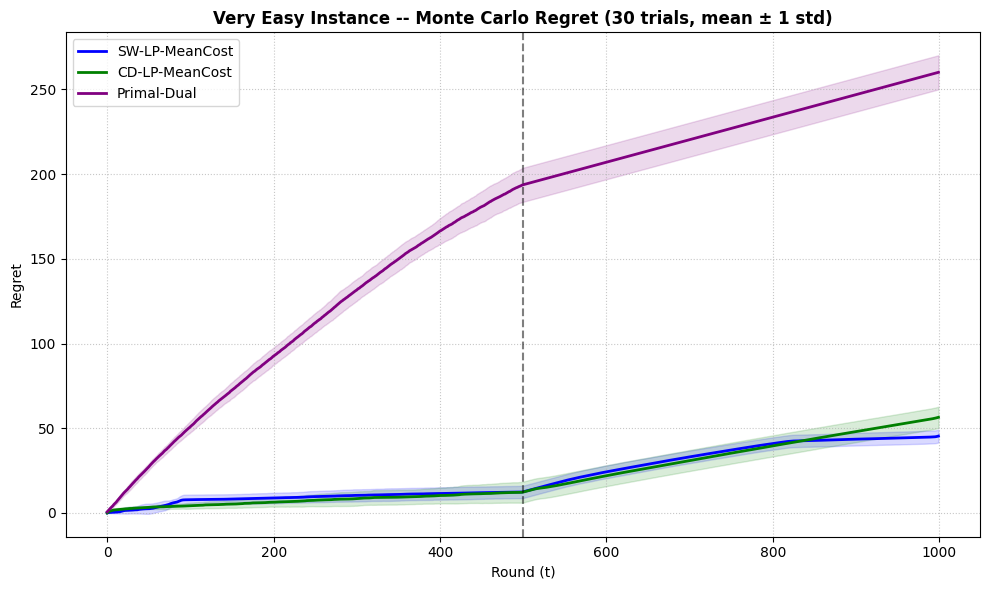


Method              Mean final regret      Std   Mean final spend
SW-LP-MeanCost                  45.39     3.80             398.63/400.00
CD-LP-MeanCost                  56.45     6.26             398.54/400.00
Primal-Dual                    260.06    10.07             208.11/400.00


In [89]:

# ══════════════════════════════════════════════════════════════════════════
# VERY EASY INSTANCE -- now across multiple seeds
# Same instance as before. Run across seeds specifically to check whether
# the earlier single-seed result (Primal-Dual losing badly AND leaving
# budget unused) is a real pattern or a fluke of that one market draw.
# ══════════════════════════════════════════════════════════════════════════
VALUES      = [1.0, 1.0]
BID_SPACE   = [0.0, 0.25, 0.5, 0.75, 1.0]
T           = 1000
B           = 0.4 * T
CONFLICT    = [[False, False], [False, False]]
BREAKPOINTS = [0, 500]
W           = 100
CD_KWARGS   = dict(warmup=15, delta=0.08, lambda_th=4.0)

CONFIGS = [
    {"means": [0.2, 0.2], "stds": [0.08, 0.08]},   # easy: cheap wins
    {"means": [0.8, 0.8], "stds": [0.08, 0.08]},   # hard: need high bids
]

AGENT_FACTORIES = {
    "SW-LP-MeanCost": lambda: SW_LP_MeanCost_Agent(VALUES, BID_SPACE, B, T, CONFLICT, W),
    "CD-LP-MeanCost": lambda: CD_LP_MeanCost_Agent(VALUES, BID_SPACE, B, T, CONFLICT, **CD_KWARGS),
    "Primal-Dual":    lambda: PrimalDualMultiCampaignAgent(VALUES, BID_SPACE, B, T, CONFLICT),
}
COLORS = {"SW-LP-MeanCost": "blue", "CD-LP-MeanCost": "green", "Primal-Dual": "purple"}
FULL_FEEDBACK_AGENTS = (PrimalDualMultiCampaignAgent,)

N_TRIALS = 30   # cheap instance (T=1000, small action space) -- affordable to run generously


if __name__ == "__main__":
    # fixed benchmark, computed once (doesn't depend on the varying seed)
    env_baseline = SlightlyNonStationaryMultiCampaignEnvironment(
        VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian',
        interval_configs=CONFIGS, seed=0
    )
    _, cumulative_baseline, _, _ = compute_joint_piecewise_clairvoyant(env_baseline, BID_SPACE)

    all_regret = {name: np.zeros((N_TRIALS, T)) for name in AGENT_FACTORIES}
    final_spend = {name: np.zeros(N_TRIALS) for name in AGENT_FACTORIES}

    for trial in range(N_TRIALS):
        for name, factory in AGENT_FACTORIES.items():
            np.random.seed(1000 + trial)   # common random numbers across agents, per trial
            agent = factory()
            env = SlightlyNonStationaryMultiCampaignEnvironment(
                VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian',
                interval_configs=CONFIGS, seed=2000 + trial   # varies ACROSS trials
            )
            expected_net = np.zeros(T)
            for t in range(T):
                bids = agent.pull_arm()
                won, rew, cost, info = env.resolve_auction(bids)
                if isinstance(agent, FULL_FEEDBACK_AGENTS):
                    agent.update(won, rew, cost, info["m_t"])
                else:
                    agent.update(won, rew, cost)
                expected_net[t] = info["expected_net"]
            all_regret[name][trial] = cumulative_baseline - np.cumsum(expected_net)
            final_spend[name][trial] = env.spent

        if (trial + 1) % 10 == 0:
            print(f"Completed {trial + 1}/{N_TRIALS} trials")

    fig, ax = plt.subplots(figsize=(10, 6))
    for name, regret_matrix in all_regret.items():
        mean_curve = regret_matrix.mean(axis=0)
        std_curve = regret_matrix.std(axis=0)
        ax.plot(mean_curve, label=name, color=COLORS[name], lw=2)
        ax.fill_between(np.arange(T), mean_curve - std_curve, mean_curve + std_curve,
                         color=COLORS[name], alpha=0.15)
    for bp in BREAKPOINTS[1:]:
        ax.axvline(bp, color='black', linestyle='--', alpha=0.5)
    ax.set_title(f'Very Easy Instance -- Monte Carlo Regret ({N_TRIALS} trials, mean ± 1 std)', fontweight='bold')
    ax.set_xlabel('Round (t)'); ax.set_ylabel('Regret')
    ax.legend(); ax.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

    print(f"\n{'Method':<18} {'Mean final regret':>18} {'Std':>8} {'Mean final spend':>18}")
    for name in AGENT_FACTORIES:
        finals = all_regret[name][:, -1]
        print(f"{name:<18} {finals.mean():18.2f} {finals.std():8.2f} {final_spend[name].mean():18.2f}/{B:.2f}")

M = 171 valid super-arms, 10 phases of ~400 rounds each
Piecewise fluid OPT per interval:
  interval 0 (t=0-400): 0.5647/round
  interval 1 (t=400-800): 0.2582/round
  interval 2 (t=800-1200): 0.2752/round
  interval 3 (t=1200-1600): 0.3280/round
  interval 4 (t=1600-2000): 0.6144/round
  interval 5 (t=2000-2400): 0.1710/round
  interval 6 (t=2400-2800): 0.4291/round
  interval 7 (t=2800-3200): 0.3207/round
  interval 8 (t=3200-3600): 0.0872/round
  interval 9 (t=3600-4000): 0.0344/round

Simulating T=4000...


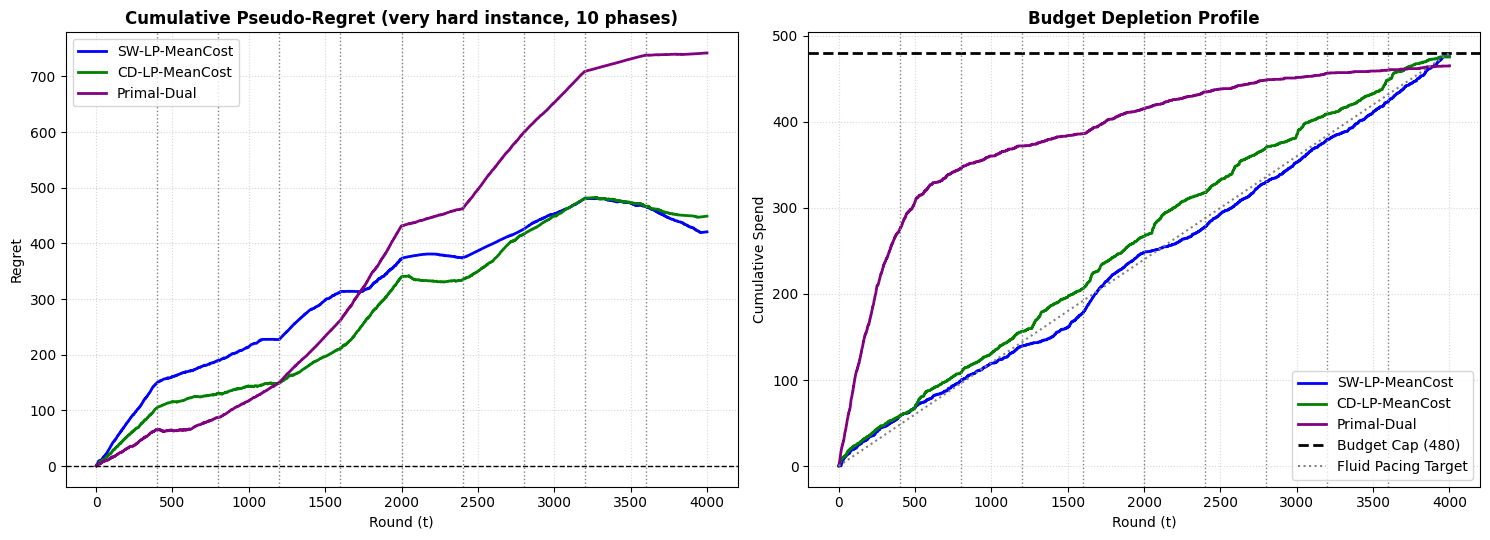


Agent            | Final Pseudo-Regret  | Final Spend     | n_resets  
---------------------------------------------------------------------------
SW-LP-MeanCost   | 420.78               | 475.65/480.00      | -
CD-LP-MeanCost   | 448.91               | 475.50/480.00      | 7
Primal-Dual      | 742.00               | 465.15/480.00      | -


In [85]:
# ══════════════════════════════════════════════════════════════════════════
# VERY HARD INSTANCE -- lots of changes
# 5 campaigns, a TRIANGLE conflict (0,1,2 mutually exclusive) PLUS an
# independent pair (3,4), 10 SHORT phases (400 rounds each) with SUBTLE,
# randomly-drawn mean shifts each phase, tight budget. Genuinely difficult:
# frequent switching relative to any reasonable W, and shifts small enough
# that noticing them at all is non-trivial.
# ══════════════════════════════════════════════════════════════════════════
VALUES      = [1.1, 1.0, 0.9, 0.7, 0.6]
BID_SPACE   = [0.0, 0.15, 0.3, 0.45, 0.6, 0.75, 0.9]
T           = 4000
B           = 0.12 * T
CONFLICT = [
    [False, True,  True,  False, False],
    [True,  False, True,  False, False],
    [True,  True,  False, False, False],
    [False, False, False, False, True ],
    [False, False, False, True,  False],
]
BREAKPOINTS = [int(f * T) for f in np.linspace(0, 0.9, 10)]  # 10 phases, 400 rounds each
SEED        = 3
W           = 200
CD_KWARGS   = dict(warmup=20, delta=0.08, lambda_th=6.0)

# subtle, randomly-drawn phase means (all in a narrow band, not dramatic swings)
_rng = np.random.default_rng(SEED)
CONFIGS = [
    {"means": _rng.uniform(0.25, 0.45, size=5).tolist(), "stds": [0.07] * 5}
    for _ in range(len(BREAKPOINTS))
]

AGENTS_SPEC = {
    "SW-LP-MeanCost": (SW_LP_MeanCost_Agent, dict(W=W)),
    "CD-LP-MeanCost": (CD_LP_MeanCost_Agent, CD_KWARGS),
    "Primal-Dual":    (PrimalDualMultiCampaignAgent, {}),
}
COLORS = {"SW-LP-MeanCost": "blue", "CD-LP-MeanCost": "green", "Primal-Dual": "purple"}
FULL_FEEDBACK_AGENTS = (PrimalDualMultiCampaignAgent,)


def make_env():
    return SlightlyNonStationaryMultiCampaignEnvironment(
        VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian',
        interval_configs=CONFIGS, seed=SEED
    )


if __name__ == "__main__":
    env_baseline = make_env()
    net_per_interval, cumulative_baseline, gammas, super_arms = compute_joint_piecewise_clairvoyant(env_baseline, BID_SPACE)
    print(f"M = {len(super_arms)} valid super-arms, {env_baseline.n_intervals} phases of ~{T // len(BREAKPOINTS)} rounds each")
    print("Piecewise fluid OPT per interval:")
    for k in range(env_baseline.n_intervals):
        print(f"  interval {k} (t={env_baseline.starts[k]}-{env_baseline.ends[k]}): {net_per_interval[k]:.4f}/round")

    agents = {name: cls(VALUES, BID_SPACE, B, T, CONFLICT, **kwargs) for name, (cls, kwargs) in AGENTS_SPEC.items()}
    envs = {name: make_env() for name in agents}
    results = {name: {"expected_net": np.zeros(T), "spend": np.zeros(T)} for name in agents}

    print(f"\nSimulating T={T}...")
    for name, agent in agents.items():
        np.random.seed(42)
        env = envs[name]
        for t in range(T):
            bids = agent.pull_arm()
            won, rew, cost, info = env.resolve_auction(bids)
            if isinstance(agent, FULL_FEEDBACK_AGENTS):
                agent.update(won, rew, cost, info["m_t"])
            else:
                agent.update(won, rew, cost)
            results[name]["expected_net"][t] = info["expected_net"]
            results[name]["spend"][t] = env.spent

    for name in agents:
        results[name]["pseudo_regret"] = cumulative_baseline - np.cumsum(results[name]["expected_net"])

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    rounds = np.arange(1, T + 1)

    for name in agents:
        axes[0].plot(rounds, results[name]["pseudo_regret"], color=COLORS[name], lw=2, label=name)
    axes[0].axhline(0, color='black', linestyle='--', lw=1)
    for bp in BREAKPOINTS[1:]:
        axes[0].axvline(bp, color='gray', linestyle=':', lw=1)
    axes[0].set_title("Cumulative Pseudo-Regret (very hard instance, 10 phases)", fontweight='bold')
    axes[0].set_xlabel("Round (t)"); axes[0].set_ylabel("Regret")
    axes[0].legend(); axes[0].grid(True, linestyle=':', alpha=0.5)

    for name in agents:
        axes[1].plot(rounds, results[name]["spend"], color=COLORS[name], lw=2, label=name)
    axes[1].axhline(B, color='black', lw=2, linestyle='--', label=f"Budget Cap ({B:.0f})")
    axes[1].plot(rounds, (B / T) * rounds, color='gray', lw=1.5, linestyle=':', label="Fluid Pacing Target")
    for bp in BREAKPOINTS[1:]:
        axes[1].axvline(bp, color='gray', linestyle=':', lw=1)
    axes[1].set_title("Budget Depletion Profile", fontweight='bold')
    axes[1].set_xlabel("Round (t)"); axes[1].set_ylabel("Cumulative Spend")
    axes[1].legend(); axes[1].grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

    print(f"\n{'Agent':<16} | {'Final Pseudo-Regret':<20} | {'Final Spend':<15} | {'n_resets':<10}")
    print("-" * 75)
    for name in agents:
        n_resets = getattr(agents[name], 'n_resets', '-')
        print(f"{name:<16} | {results[name]['pseudo_regret'][-1]:<20.2f} | {results[name]['spend'][-1]:.2f}/{B:.2f}      | {n_resets}")

Completed 10/30 trials
Completed 20/30 trials
Completed 30/30 trials


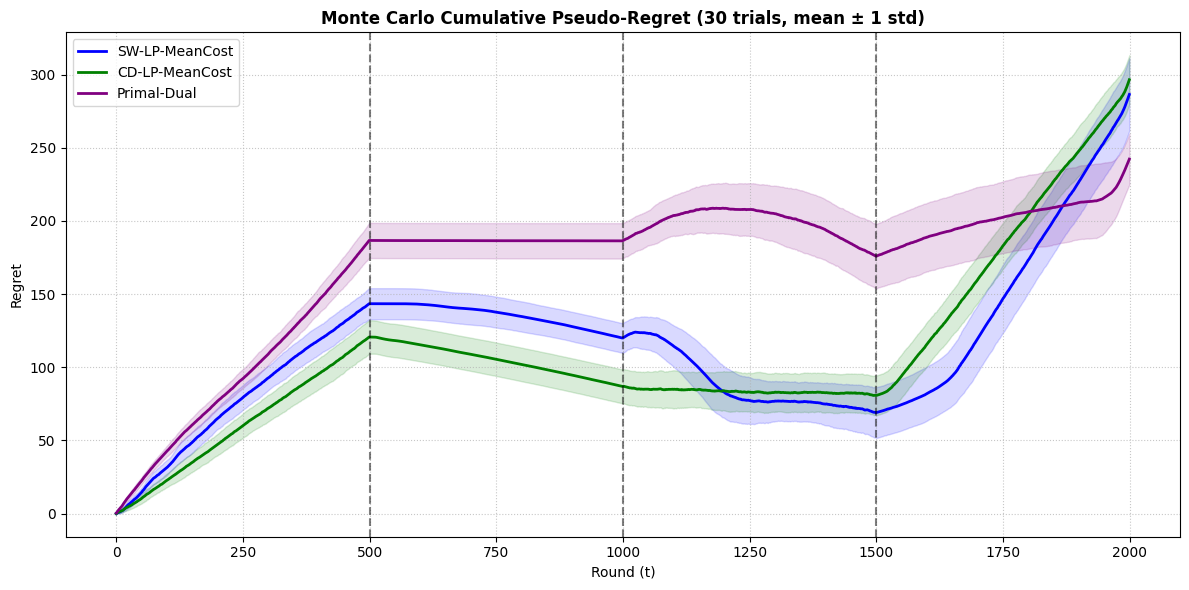


Method              Mean final regret      Std      Min      Max
SW-LP-MeanCost                 286.38    24.70   239.30   355.84
CD-LP-MeanCost                 296.45    16.70   259.67   330.92
Primal-Dual                    242.20    17.32   209.79   277.75


In [88]:
#── INSTANCE: the "main" 4-phase instance used throughout ───────────────────
VALUES      = [1.5, 1.2]
BID_SPACE   = [0.0, 0.5, 1.0, 1.5]
T           = 2000
B           = 0.3 * T
CONFLICT    = [[False, True], [True, False]]
BREAKPOINTS = [0, 500, 1000, 1500]
W           = 200
CD_KWARGS   = dict(warmup=20, delta=0.08, lambda_th=6.0)   # tuned, verified elsewhere in this project

CONFIGS = [
    {"means": [0.4, 0.3], "stds": [0.1,  0.1 ]},
    {"means": [1.1, 1.0], "stds": [0.2,  0.2 ]},
    {"means": [0.3, 1.2], "stds": [0.1,  0.2 ]},
    {"means": [0.2, 0.1], "stds": [0.05, 0.05]},
]

FULL_FEEDBACK_AGENTS = (PrimalDualMultiCampaignAgent,)
COLORS = {"SW-LP-MeanCost": "blue", "CD-LP-MeanCost": "green", "Primal-Dual": "purple"}

N_TRIALS = 30   # reduce if this is too slow on your machine

agent_factories = {
    "SW-LP-MeanCost": lambda: SW_LP_MeanCost_Agent(VALUES, BID_SPACE, B, T, CONFLICT, W),
    "CD-LP-MeanCost": lambda: CD_LP_MeanCost_Agent(VALUES, BID_SPACE, B, T, CONFLICT, **CD_KWARGS),
    "Primal-Dual":    lambda: PrimalDualMultiCampaignAgent(VALUES, BID_SPACE, B, T, CONFLICT),
}


if __name__ == "__main__":
    # single fixed instance used only to compute the (fixed) piecewise
    # clairvoyant benchmark -- the per-trial envs below vary the market
    # draw across trials, but always score against this SAME benchmark
    env_baseline = SlightlyNonStationaryMultiCampaignEnvironment(
        VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian',
        interval_configs=CONFIGS, seed=0
    )
    _, cumulative_baseline, _, _ = compute_joint_piecewise_clairvoyant(env_baseline, BID_SPACE)

    all_regrets = {name: np.zeros((N_TRIALS, T)) for name in agent_factories}

    for trial in range(N_TRIALS):
        for name, factory in agent_factories.items():
            np.random.seed(1000 + trial)   # common random numbers across agents, per trial
            agent = factory()
            env = SlightlyNonStationaryMultiCampaignEnvironment(
                VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian',
                interval_configs=CONFIGS, seed=2000 + trial   # varies ACROSS trials
            )
            expected_net = np.zeros(T)
            for t in range(T):
                bids = agent.pull_arm()
                won, rew, cost, info = env.resolve_auction(bids)
                if isinstance(agent, FULL_FEEDBACK_AGENTS):
                    agent.update(won, rew, cost, info["m_t"])
                else:
                    agent.update(won, rew, cost)
                expected_net[t] = info["expected_net"]
            all_regrets[name][trial] = cumulative_baseline - np.cumsum(expected_net)

        if (trial + 1) % 10 == 0:
            print(f"Completed {trial + 1}/{N_TRIALS} trials")

    fig, ax = plt.subplots(figsize=(12, 6))
    for name, regret_matrix in all_regrets.items():
        mean_curve = regret_matrix.mean(axis=0)
        std_curve = regret_matrix.std(axis=0)
        ax.plot(mean_curve, label=name, color=COLORS[name], lw=2)
        ax.fill_between(np.arange(T), mean_curve - std_curve, mean_curve + std_curve,
                         color=COLORS[name], alpha=0.15)
    for bp in BREAKPOINTS[1:]:
        ax.axvline(bp, color='black', linestyle='--', alpha=0.5)
    ax.set_title(f'Monte Carlo Cumulative Pseudo-Regret ({N_TRIALS} trials, mean ± 1 std)', fontweight='bold')
    ax.set_xlabel('Round (t)'); ax.set_ylabel('Regret')
    ax.legend(); ax.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

    print(f"\n{'Method':<18} {'Mean final regret':>18} {'Std':>8} {'Min':>8} {'Max':>8}")
    for name, regret_matrix in all_regrets.items():
        finals = regret_matrix[:, -1]
        print(f"{name:<18} {finals.mean():18.2f} {finals.std():8.2f} {finals.min():8.2f} {finals.max():8.2f}")